# RCT Data-Literacy — Statistical Analysis (v3, live SAP)

**This notebook implements the pre-registered SAP as it stands after decisions D1–D9**
(`sections/SAP_04_07.tex` + `sections/SAP_appendix_04_07.tex`). It supersedes v2, which still
ran the pre-D9 architecture (co-primary outcomes, α split 0.025, wave-averaged estimand, flat
Holm, MAILS covariate). v3 changes, each traceable to a decision:

- **D2 — immediate wave is the estimand.** `Wave` is a **0/1 dummy** (immediate = 0); arm
  coefficients β₁,β₂ are the **immediate-wave** effects, not wave averages.
- **D3 — accuracy is the sole primary at full α = 0.05.** Success time is a **key secondary**.
  No 0.025 split.
- **D3 — fixed-sequence gatekeeper** H1ₐ → H2ₐ → supporting, replacing flat Holm.
- **D6 — H2ₐ non-inferiority** test: TOST / 90 % CI vs **Δ = 8.5 pp**, required to hold in
  **ITT ∧ per-protocol**.
- **All confirmatory tests one-sided** (directional), each with a two-sided 95 % CI.
- **D7 — covariate = Mini-VLAT + a single behaviourally-anchored `AIUse` item** (not the
  10-item MAILS). MAILS is kept for the descriptive baseline table only.
- **D9-R1 — persistence H5ₐ = delayed-wave simple effect β₂+β₅** (one-sided), not the
  interaction alone.
- **D9-R2 — success-time Cox carries arm×wave interactions** (θ₂ = immediate log-HR).
- Secondary confirmatory family **{H4ₐ, H5ₐ}** = one-sided Holm; success-time = its own Holm
  family (supporting); productivity = BH-FDR.

**Estimators are shared, not inlined.** The fitting/contrast/gatekeeper code lives in
`sap_estimators.py` (same folder) and is imported here **and** by the Monte Carlo validation
notebook (`rct_data_literacy_sap_validation.ipynb`), so the validation exercises exactly the
code that runs on real data.

**Dummy-data note.** On the current pipeline-test export the delayed wave, the answer key, and
the `AIUse` item are simulated/placeholder (loud warnings). The confirmatory results are on the
proportion / hazard scale and run end-to-end so the machinery is validated; see *Before the real
run*. Nothing here is interpreted as a finding on dummy data.

## 0. Setup and configuration

In [1]:
import json, re, warnings
import numpy as np
import pandas as pd
import scipy.stats as st
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from lifelines import CoxPHFitter, LogNormalAFTFitter
from lifelines.statistics import proportional_hazard_test

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*convergence.*", category=RuntimeWarning)
warnings.filterwarnings("ignore", message=".*divide by zero.*")
warnings.filterwarnings("ignore", message=".*invalid value.*")

CONFIG = dict(
    DATA_PATH_CANDIDATES=[
        "/Users/brunokneffel/Library/Mobile Documents/com~apple~CloudDocs/gymnasium steglitz/B.SC Frankfurt School/Oxford/Thesis/WIP/thesis-latex/old dataset/Final dataset/RCT_DataLiteracy_DL_BK_July 20, 2026_10.55.csv",
    ],
    # delayed-wave export (separate Qualtrics survey); post_test_2_q is merged onto the
    # main dataframe by PROLIFIC_PID in the load cell.
    DELAYED_DATA_PATH_CANDIDATES=[
        "/Users/brunokneffel/Library/Mobile Documents/com~apple~CloudDocs/gymnasium steglitz/B.SC Frankfurt School/Oxford/Thesis/WIP/thesis-latex/old dataset/Final dataset/RCT_DelayedRetest_PCP (rebuilt)_July 21, 2026_05.55.csv",
    ],
    SEED=2026,
    # --- answer key (SUPPLY FOR REAL DATA) --------------------------------------
    ANSWER_KEY={
        "pcp_rem_fa_1": "A", "pcp_und_fa_1": "B", "pcp_ana_fa_1": "D", "pcp_eval_fa_10": "A",
        "pcp_rem_fa_2": "A", "pcp_und_fa_2": "B", "pcp_ana_fa_2": "B", "pcp_eval_fa_11": "A",
        "pcp_rem_sa_1": "A", "pcp_rem_sa_2": "A", "pcp_rem_sa_3": "C", "pcp_rem_sa_4": "B",
        "pcp_und_sa_1": "B", "pcp_und_sa_2": "B", "pcp_und_sa_3": "D", "pcp_und_sa_4": "B",
        "pcp_ana_sa_1": "B", "pcp_ana_sa_2": "B", "pcp_ana_sa_3": "A", "pcp_ana_sa_9": "C",
        "pcp_eval_sa_1": "A", "pcp_eval_sa_2": "A", "pcp_eval_sa_3": "A", "pcp_eval_sa_4": "A",
        "pcp_rem_sa_5": "B", "pcp_rem_sa_6": "C", "pcp_rem_sa_7": "B", "pcp_rem_sa_8": "A",
        "pcp_und_sa_5": "B", "pcp_und_sa_6": "A", "pcp_und_sa_7": "C", "pcp_und_sa_8": "B",
        "pcp_ana_sa_5": "B", "pcp_ana_sa_6": "A", "pcp_ana_sa_7": "B", "pcp_ana_sa_8": "A",
        "pcp_eval_sa_5": "D", "pcp_eval_sa_6": "A", "pcp_eval_sa_7": "A", "pcp_eval_sa_8": "A",
    },
    GENERATE_DUMMY_KEY=False,
    IDK_OPTION={
        "pcp_rem_fa_1": "C", "pcp_und_fa_1": "D", "pcp_ana_fa_1": "E", "pcp_eval_fa_10": "E",
        "pcp_rem_fa_2": "C", "pcp_und_fa_2": "D", "pcp_ana_fa_2": "E", "pcp_eval_fa_11": "E",
        "pcp_rem_sa_1": "C", "pcp_rem_sa_2": "C", "pcp_rem_sa_3": "G", "pcp_rem_sa_4": "C",
        "pcp_und_sa_1": "D", "pcp_und_sa_2": "D", "pcp_und_sa_3": "F", "pcp_und_sa_4": "F",
        "pcp_ana_sa_1": "E", "pcp_ana_sa_2": "E", "pcp_ana_sa_3": "E", "pcp_ana_sa_9": "E",
        "pcp_eval_sa_1": "E", "pcp_eval_sa_2": "F", "pcp_eval_sa_3": "E", "pcp_eval_sa_4": "E",
        "pcp_rem_sa_5": "C", "pcp_rem_sa_6": "G", "pcp_rem_sa_7": "G", "pcp_rem_sa_8": "C",
        "pcp_und_sa_5": "D", "pcp_und_sa_6": "E", "pcp_und_sa_7": "E", "pcp_und_sa_8": "E",
        "pcp_ana_sa_5": "C", "pcp_ana_sa_6": "C", "pcp_ana_sa_7": "C", "pcp_ana_sa_8": "D",
        "pcp_eval_sa_5": "E", "pcp_eval_sa_6": "E", "pcp_eval_sa_7": "E", "pcp_eval_sa_8": "E",
    },
    # --- delayed wave ------------------------------------------------------------
    DELAYED_PACKED_CANDIDATES=["post_test_2_q", "delayed_post_test_q"],
    SIMULATE_DELAYED=False,
    # --- covariates (SAP D7): Mini-VLAT + single anchored GenAI-usage item -------
    AIUSE_ITEM="Q71",         # GenAI-usage item on the live survey (mapped via AIUSE_LEVELS)
    AIUSE_LEVELS={"never": 0, "less than once a month": 1, "a few times a month": 2,
                  "weekly": 3, "a few times a week": 3, "daily": 4, "several times a day": 5},
    # --- descriptive-only baseline scales (NOT model covariates) ----------------
    MAILS_ITEMS=["Q4","Q6","Q7","Q8","Q9","Q10","Q11","Q12","Q13","Q14"],
    IL_ITEMS=["IL 1","IL 2","IL 3"], EL_ITEMS=["EL 1","EL 2","EL 3"],
    GL_ITEMS=["GL 1","GL 2","GL 3"],
    SGL_ITEMS=["Q26_1","Q26_2","Q26_3","Q26_4","Q26_5","Q26_6"],
    CONFIDENCE_ITEMS=["Q2_1","Q2_2","Q2_3","Q2_4","Q2_5"],
    GENDER_COL="Q40",
    # --- pre-registered thresholds (LOCK before registration) -------------------
    SPEEDER_MEDIAN_RT_MS=1000,
    ADOPTION_LATENCY_THRESHOLD_S=5,   # direct-adoption cutoff (s); LOCK FROM PILOT delta distribution (measure-first)
    RT_CAP_S=None,            # administrative success-time cap [VALUE]; None = no cap
    # --- inference (SAP) --------------------------------------------------------
    ALPHA=0.05,              # single confirmatory level (D3) — one-sided
    NI_MARGIN_PROP=0.085,    # D6: Delta = 8.5 pp on the 0-1 proportion scale
    N_PERMUTATIONS=2000,      # set 10000 for the real run
    N_MICE=50,               # set 50 for the real run (D9/SAP)
    ARM_ORDER=["google","socratic","unrestricted"],
)
rng = np.random.default_rng(CONFIG["SEED"])
ARM_ORDER = CONFIG["ARM_ORDER"]
ALPHA = CONFIG["ALPHA"]
DELTA = CONFIG["NI_MARGIN_PROP"]
pd.set_option("display.width", 170)

# --- estimators live in sap_estimators.py (same dir): the single source of truth
# shared with the Monte Carlo validation notebook, so validation exercises THIS code.
from sap_estimators import (z_onesided_p, ci95, ci90, lincom, fit_primary_acc,
                            gatekeeper, h5a_simple_effect, holm_family,
                            fit_cox_st, cox_lincom, fit_bloom_gee, h4a_from_gee,
                            lee_bounds, kr20, adoption_latency, fit_aft_fallback)

print("Setup complete. Single primary at one-sided alpha =", ALPHA,
      "| NI margin Delta =", DELTA, "(", DELTA*100, "pp )")

Setup complete. Single primary at one-sided alpha = 0.05 | NI margin Delta = 0.085 ( 8.5 pp )


## 1. Data cleaning
### 1.1 Load the Qualtrics export
Qualtrics writes three header rows; rows 2–3 are dropped. Validity filters follow the
pre-registration (finished, consented, not flagged excluded, core blocks present).

In [2]:
from pathlib import Path
path = next((p for p in CONFIG["DATA_PATH_CANDIDATES"] if Path(p).exists()), None)
assert path is not None, "CSV not found; add its path to CONFIG['DATA_PATH_CANDIDATES']"
raw = pd.read_csv(path, skiprows=[1, 2])
print(f"Loaded {raw.shape[0]} records x {raw.shape[1]} columns")

df = raw.copy()
if "Finished" in df:
    df = df[df["Finished"].astype(str).str.upper().isin(["TRUE", "1"])]
if "excluded" in df and df["excluded"].notna().any():
    df = df[~df["excluded"].astype(str).str.lower().isin(["true", "1", "yes"])]
if "consent_choice" in df and df["consent_choice"].notna().any():
    df = df[df["consent_choice"].astype(str).str.lower().str.startswith(("agree", "yes", "i agree"))]
df["pid"] = df.get("PROLIFIC_PID", df["ResponseId"]).fillna(df["ResponseId"])
df = df.drop_duplicates(subset="pid").reset_index(drop=True)
df = df[df["pid"] != "P001"].copy() # the prolific Id is the one of the Researcher for test purposes. Included to make sure everything is 


# --- Bind the delayed-wave survey (separate Qualtrics export) by PROLIFIC_PID ----------
# The 72h retest is a second survey; its post_test_2_q is joined here so the delayed-unpack
# cell finds it as a column on df (via DELAYED_PACKED_CANDIDATES). Left-join keeps all rows.
_dpath = next((p for p in CONFIG.get("DELAYED_DATA_PATH_CANDIDATES", []) if Path(p).exists()), None)
if _dpath is not None:
    _dl = pd.read_csv(_dpath, skiprows=[1, 2], low_memory=False)
    _key = "PROLIFIC_PID" if "PROLIFIC_PID" in _dl.columns else "participant_id"
    _pk = [c for c in CONFIG["DELAYED_PACKED_CANDIDATES"] if c in _dl.columns]
    if _pk:
        _dsub = (_dl[_dl[_key].notna() & _dl[_pk[0]].notna()][[_key, _pk[0]]]
                 .rename(columns={_key: "pid", _pk[0]: "post_test_2_q"}).drop_duplicates("pid"))
        df = df.drop(columns=[c for c in ["post_test_2_q"] if c in df.columns])
        df = df.merge(_dsub, on="pid", how="left")
        print(f"Merged delayed wave from {Path(_dpath).name}: "
              f"{df['post_test_2_q'].notna().sum()} participant(s) with a delayed block")
    else:
        print(f"Delayed file {Path(_dpath).name} has no known post-test column; merge skipped")
else:
    print("No delayed-wave export found; delayed wave will simulate/skip per CONFIG")
# primary analysis set (SAP): randomised participants with >=1 immediate-wave item.
df = df[df[["vlat_train_responses", "post_test_1_q"]].notna().all(axis=1)].copy()
print(f"After validity filters: {len(df)} participants")

Loaded 247 records x 440 columns
Merged delayed wave from RCT_DelayedRetest_PCP (rebuilt)_July 21, 2026_05.55.csv: 174 participant(s) with a delayed block
After validity filters: 218 participants


### 1.2 Arm coding
`arm` carries the LLM split; `Condition == 'SEARCH'` rows are the Google active control.
Arms are ordered google < socratic < unrestricted (offloading gradient) for the trend tests.

In [3]:
df["arm"] = df["arm"].astype(str).str.strip().str.lower().replace({"nan": np.nan})
df.loc[df["arm"].isna() & df["Condition"].astype(str).str.upper().eq("SEARCH"), "arm"] = "google"
df = df[df["arm"].isin(ARM_ORDER)].copy()
df["arm"] = pd.Categorical(df["arm"], categories=ARM_ORDER, ordered=True)
df["socratic"]     = (df["arm"] == "socratic").astype(int)
df["unrestricted"] = (df["arm"] == "unrestricted").astype(int)
print(df["arm"].value_counts().reindex(ARM_ORDER))

arm
google          69
socratic        72
unrestricted    77
Name: count, dtype: int64


### 1.3 Unpack the packed item columns
`post_test_1_q` (16 immediate items) and `vlat_train_responses` (8 aided items + per-item
interaction log) are JSON arrays exploded to one row per participant×item. Bloom level is read
from the item id (`pcp_{rem|und|ana|eval}_...`).

In [4]:
BLOOM = {"rem": "Remember", "und": "Understand", "ana": "Analyze", "eval": "Evaluate"}

def parse_json(cell):
    try: return json.loads(cell)
    except (TypeError, ValueError): return None

def bloom_of(item_id):
    m = re.search(r"pcp_(rem|und|ana|eval)_", str(item_id))
    return BLOOM.get(m.group(1)) if m else None

def summarise_interaction(inter):
    out = dict(mode=None, n_turns=0, n_queries=0, n_clicks=0,
               judge_fidelities=[], n_regen=0, prompts=[], responses=[], queries=[], turn_ts_present=False, response_ts=[], search_ts=[])
    if not isinstance(inter, dict): return out
    out["mode"] = inter.get("mode")
    for t in inter.get("turns", []) or []:
        out["n_turns"] += 1
        out["prompts"].append(str(t.get("prompt", "")))
        out["responses"].append(str(t.get("response", "")))
        j = t.get("judge") or {}
        if "fidelity" in j: out["judge_fidelities"].append(j["fidelity"])
        out["n_regen"] += int(bool(j.get("active_regen")))
        if t.get("response_ts"): out["response_ts"].append(t["response_ts"])   # ADDITIVE: assistant-msg wall-clock ts
        if any(k in t for k in ("ts_ms", "timestamp", "t_ms", "ms_since_item_start", "response_ts")):
            out["turn_ts_present"] = True
    for s in inter.get("searches", []) or []:
        out["n_queries"] += 1
        out["queries"].append(str(s.get("query", "")))
        out["n_clicks"] += len(s.get("clicks", []) or [])
        if s.get("query_ts"): out["search_ts"].append(s["query_ts"])            # ADDITIVE
        for _c in (s.get("clicks", []) or []):
            if _c.get("ts"): out["search_ts"].append(_c["ts"])                  # ADDITIVE
    return out

def unpack(df, col, wave):
    rows = []
    for _, r in df.iterrows():
        items = parse_json(r.get(col))
        if not items: continue
        for pos, it in enumerate(items):
            iid = str(it.get("raw_id") or it.get("id") or "").removeprefix("vlat_")
            inter = summarise_interaction(it.get("interaction"))
            ans = it.get("answer")
            ans = (str(ans).strip() or None) if ans is not None else None
            rows.append(dict(
                pid=r["pid"], arm=r["arm"], wave=wave, position=pos, item_id=iid,
                bloom=bloom_of(iid), answer=ans,
                rt_ms=it.get("rt_ms", it.get("time_ms")), timeout=bool(it.get("timeout", False)),
                **{k: inter[k] for k in ("mode","n_turns","n_queries","n_clicks",
                    "judge_fidelities","n_regen","prompts","responses","queries","turn_ts_present","response_ts","search_ts")}, answer_ts=it.get("answer_ts")))
    out = pd.DataFrame(rows)
    if len(out):
        out["rt_ms"] = pd.to_numeric(out["rt_ms"], errors="coerce")
        empty = out["answer"].isna() & out["rt_ms"].isna()
        if empty.any():
            print(f"  {col} ({wave}): dropped {int(empty.sum())} empty item records (block not administered)")
        out = out[~empty].reset_index(drop=True)
    return out

items_train     = unpack(df, "vlat_train_responses", "train")
items_immediate = unpack(df, "post_test_1_q", "immediate")
print(f"train items: {len(items_train)} | immediate items: {len(items_immediate)}")
print("Bloom counts (immediate):"); print(items_immediate["bloom"].value_counts())

train items: 1744 | immediate items: 3488
Bloom counts (immediate):
bloom
Analyze       872
Understand    872
Evaluate      872
Remember      872
Name: count, dtype: int64


### 1.4 Mini-VLAT and the two model covariates (SAP D7)
Model covariates are **Mini-VLAT** (visualisation-literacy baseline) and a **single
behaviourally-anchored `AIUse` item**. The 10-item MAILS scale is computed for the *descriptive
baseline table only* — the SAP explicitly rejected it as the covariate (reference-group effect).
Column matching is case-insensitive (the export ships `Il 1`, not `IL 1`).

In [5]:
def cols_ci(names):
    low = {c.lower(): c for c in df.columns}
    return [low[n.lower()] for n in names if n.lower() in low]

def mean_of(names):
    have = cols_ci(names)
    return pd.to_numeric(df[have].stack(), errors="coerce").groupby(level=0).mean() if have else np.nan

# Mini-VLAT baseline covariate (SAP D7), scored against the published Mini-VLAT V2 answer key
# (Pandey & Ottley 2023). The survey exports the participant's SELECTED answer per item in
# minivlat_<id>_response (letters for MC items, "True"/"False" for T/F); correctness is scored
# HERE, with timeout / "I don't know" (omit) = incorrect, mirroring the PCP ANSWER_KEY/score()
# path. NOTE: the survey's own `minivlat_score` column is an ATTEMPTS count (non-omit,
# non-timeout), NOT the graded score, so it must not be used as the covariate.
MINIVLAT_KEY = {1: "False", 6: "C", 10: "C", 16: "True", 19: "A", 22: "C",
                33: "C", 35: "A", 41: "C", 48: "A", 57: "C", 61: "False"}
mv_resp = [c for c in df.columns if re.fullmatch(r"minivlat_\d+_response", c)]
if not mv_resp:
    raise KeyError("Mini-VLAT: no minivlat_<id>_response columns in the export.")
mv_long = df[["pid"] + mv_resp].melt("pid", var_name="item", value_name="resp")
mv_long["mv_id"]  = mv_long["item"].str.extract(r"minivlat_(\d+)_response").astype(int)
mv_long["mv_key"] = mv_long["mv_id"].map(MINIVLAT_KEY).astype(str)
mv_long["correct"] = (mv_long["resp"].astype(str) == mv_long["mv_key"]).astype(int)  # omit/timeout != key -> 0
df["minivlat_recomputed"] = df["pid"].map(mv_long.groupby("pid")["correct"].sum())
df["minivlat_c"] = (df["minivlat_recomputed"] - df["minivlat_recomputed"].mean()).fillna(0)

# AIUse: the SAP covariate. Real column -> ordinal map; else SEEDED placeholder (dummy only).
aiuse_col = CONFIG.get("AIUSE_ITEM")
if aiuse_col and aiuse_col in df.columns:
    lv = CONFIG["AIUSE_LEVELS"]
    df["aiuse"] = df[aiuse_col].astype(str).str.strip().str.lower().map(lv)
    if df["aiuse"].isna().all():
        df["aiuse"] = pd.to_numeric(df[aiuse_col], errors="coerce")
    print(f"AIUse covariate from column '{aiuse_col}'.")
else:
    print("=" * 78)
    print("WARNING: AIUse anchored item NOT mapped -> SEEDED PLACEHOLDER (0-5), dummy demo only.")
    print("Set CONFIG['AIUSE_ITEM'] to the GenAI-usage column before analysing real data.")
    print("=" * 78)
    df["aiuse"] = rng.integers(0, 6, size=len(df)).astype(float)
df["aiuse_c"] = (df["aiuse"] - df["aiuse"].mean()).fillna(0)

# descriptive-only baseline scales (never enter a model)
df["mails"]      = mean_of(CONFIG["MAILS_ITEMS"])
df["confidence"] = mean_of(CONFIG["CONFIDENCE_ITEMS"])
df["IL_ave"] = mean_of(CONFIG["IL_ITEMS"]); df["EL_ave"] = mean_of(CONFIG["EL_ITEMS"])
df["GL_ave"] = mean_of(CONFIG["GL_ITEMS"])
sgl_cols = cols_ci(CONFIG["SGL_ITEMS"])
df["sgl"] = (df[sgl_cols].apply(lambda s: pd.to_numeric(s.astype(str).str.extract(r"^(\d+)")[0], errors="coerce")).mean(axis=1)
             if sgl_cols else np.nan)
gcol = cols_ci([CONFIG["GENDER_COL"]])
df["female"] = (df[gcol[0]].astype(str).str.lower().eq("female").astype(int) if gcol else 0)
df[["pid","arm","minivlat_recomputed","minivlat_c","aiuse","aiuse_c","mails"]].head()

AIUse covariate from column 'Q71'.


,pid,arm,minivlat_recomputed,minivlat_c,aiuse,aiuse_c,mails
0,P002,unrestricted,6,-1.788991,3,-1.059633,NaN
1,P003,google,7,-0.788991,4,-0.059633,NaN
2,P004,google,11,3.211009,5,0.940367,NaN
3,P005,unrestricted,8,0.211009,5,0.940367,NaN
4,P006,google,10,2.211009,2,-2.059633,NaN


### 1.5 Answer key and correctness
Scoring per the pre-registration: correct = key match; timeouts and "I do not know" score
incorrect for accuracy and are right-censored for success time. Supply `CONFIG['ANSWER_KEY']`
and `IDK_OPTION` for the real run.

In [6]:
all_items = pd.concat([items_train, items_immediate])
key = dict(CONFIG["ANSWER_KEY"])
if not key and CONFIG["GENERATE_DUMMY_KEY"]:
    print("WARNING: PLACEHOLDER ANSWER KEY (seeded) — dummy demonstration only.")
    for iid, opts in all_items.groupby("item_id")["answer"].unique().items():
        opts = sorted(o for o in opts if o)
        key[iid] = rng.choice(opts if opts else ["A"])
assert key, "No answer key available."

def score(items):
    items = items.copy()
    items["key"] = items["item_id"].map(key)
    items["idk"] = items["answer"].eq(items["item_id"].map(CONFIG["IDK_OPTION"])) if CONFIG["IDK_OPTION"] else False  # v5 fix (D13): map item_id->IDK letter (v4 answer.eq(dict) was always False)
    items["correct"] = ((items["answer"] == items["key"]) & ~items["timeout"] & ~items["idk"]).astype(int)
    return items

items_train, items_immediate = score(items_train), score(items_immediate)
print(f"Aided accuracy: {items_train['correct'].mean():.2f} | immediate accuracy: {items_immediate['correct'].mean():.2f}")

Aided accuracy: 0.66 | immediate accuracy: 0.74


### 1.6 Delayed wave
No live PCP delayed column is populated in this export (the `cr_delayed_*` block is the
superseded critical-reasoning instrument), so with `SIMULATE_DELAYED=True` a seeded delayed wave
is generated purely to exercise the two-wave machinery. Set the flag to `False` for real data.

In [7]:
delayed_col = next((c for c in CONFIG["DELAYED_PACKED_CANDIDATES"]
                    if c in df.columns and df[c].notna().any()), None)
if delayed_col:
    items_delayed = score(unpack(df, delayed_col, "delayed")); SIMULATED = False
elif CONFIG["SIMULATE_DELAYED"]:
    SIMULATED = True
    print("=" * 78); print("WARNING: SIMULATED DELAYED WAVE (seeded) — dummy demonstration only."); print("=" * 78)
    returners = items_immediate["pid"].unique()
    dropout = rng.choice(returners, size=max(1, len(returners) // 7), replace=False)
    sim = items_immediate[~items_immediate["pid"].isin(dropout)].copy()
    sim["wave"] = "delayed"
    opts = sorted({a for a in all_items["answer"].dropna()})
    flip = rng.random(len(sim)) < 0.25
    sim.loc[flip, "answer"] = rng.choice(opts, size=flip.sum())
    sim["rt_ms"] = (sim["rt_ms"] * np.exp(rng.normal(0, 0.2, len(sim)))).round()
    items_delayed = score(sim.drop(columns=["key", "idk", "correct"]))
    print(f"Simulated delayed wave: {items_delayed['pid'].nunique()} returners ({len(dropout)} dropout)")
else:
    items_delayed = pd.DataFrame(columns=items_immediate.columns); SIMULATED = False

### 1.7 Assemble analysis frames — **Wave as a 0/1 dummy (D2)**
`acc_pw` (participant×wave accuracy, mixed-model input) now codes **`wave_d` = 0 immediate /
1 delayed**, so the arm coefficients are the immediate-wave estimand and the arm×wave terms carry
persistence — replacing v2's ±0.5 effect coding. `surv` is the item-level censored-time frame with
`wave_d` and precomputed arm×wave interaction columns for the Cox model.

In [8]:
covars = df[["pid","arm","socratic","unrestricted","minivlat_recomputed","minivlat_c",
             "aiuse","aiuse_c","confidence","IL_ave","EL_ave","GL_ave","mails"]].copy()

unassisted = pd.concat([items_immediate, items_delayed], ignore_index=True)
unassisted["wave"] = pd.Categorical(unassisted["wave"], ["immediate","delayed"], ordered=True)
_ORDER = {"Remember":"lower","Understand":"lower","Analyze":"higher","Evaluate":"higher"}
for _f in (items_train, items_immediate, items_delayed, unassisted):
    if len(_f): _f["order"] = _f["bloom"].map(_ORDER)

# ADDITIVE: per-aided-item answer-adoption latency delta (last tool interaction -> answer submission).
# delta = answer_ts - max(response_ts ∪ search_ts), seconds; NaN when either absent (guard).
def _last_tool_ts(row):
    _t = [pd.Timestamp(x) for x in (list(row.get("response_ts") or []) + list(row.get("search_ts") or [])) if x]
    return max(_t) if _t else pd.NaT
if len(items_train):
    items_train["answer_ts"] = items_train.get("answer_ts")
    _lt = pd.to_datetime(items_train.apply(_last_tool_ts, axis=1), errors="coerce", utc=True)
    _at = pd.to_datetime(items_train["answer_ts"], errors="coerce", utc=True)
    items_train["adopt_delta_s"] = (_at - _lt).dt.total_seconds()
    items_train.loc[items_train["adopt_delta_s"] < 0, "adopt_delta_s"] = np.nan

# participant x wave accuracy; Wave = 0/1 dummy (immediate reference)  <-- D2
acc_pw = (unassisted.groupby(["pid","wave"], observed=True)
          .agg(acc=("correct","mean"), n_items=("correct","size"),
               total_time_ms=("rt_ms","sum"), n_correct=("correct","sum"))
          .reset_index().merge(covars, on="pid"))
acc_pw["wave_d"] = (acc_pw["wave"] == "delayed").astype(int)

# item-level survival frame: event = correct answer; censored otherwise. RT cap optional.
surv = unassisted.merge(covars.drop(columns="arm"), on="pid").copy()
surv["duration_s"] = surv["rt_ms"].clip(lower=50) / 1000.0
if CONFIG["RT_CAP_S"]:
    surv["duration_s"] = surv["duration_s"].clip(upper=CONFIG["RT_CAP_S"])
surv["event"] = surv["correct"]
surv["wave_d"] = (surv["wave"] == "delayed").astype(int)
surv["soc_wave"] = surv["socratic"] * surv["wave_d"]     # arm x wave interaction cols (D9-R2)
surv["unr_wave"] = surv["unrestricted"] * surv["wave_d"]

# aided (training) productivity frame
aided = (items_train.groupby("pid")
         .agg(aided_acc=("correct","mean"), n_items=("correct","size"), n_correct=("correct","sum"),
              total_time_ms=("rt_ms","sum"), n_turns=("n_turns","sum"),
              n_queries=("n_queries","sum"), n_clicks=("n_clicks","sum"))
         .reset_index().merge(covars, on="pid"))
aided["minutes"] = aided["total_time_ms"] / 60000.0
aided["rcs"] = aided["n_correct"] / aided["minutes"]
aided["log_rcs"] = np.log(aided["rcs"].clip(lower=1e-3))
aided["log_time_per_item"] = np.log((aided["total_time_ms"] / aided["n_items"]).clip(lower=1))
aided["engaged"] = ((aided["n_turns"] + aided["n_queries"]) > 0).astype(int)
aided_surv = items_train.merge(covars.drop(columns="arm"), on="pid").copy()
aided_surv["duration_s"] = aided_surv["rt_ms"].clip(lower=50) / 1000.0
aided_surv["event"] = aided_surv["correct"]

pooled = acc_pw.groupby("pid").agg(acc=("acc","mean"), arm=("arm","first")).reset_index()
med_tc = (surv[surv.event == 1].groupby("pid")["duration_s"].median()
          .rename("median_t_correct").reset_index().merge(covars[["pid","arm"]], on="pid"))
med_rt = unassisted.groupby("pid")["rt_ms"].median()
speeders = set(med_rt[med_rt < CONFIG["SPEEDER_MEDIAN_RT_MS"]].index)
print(f"acc_pw {acc_pw.shape} | surv {surv.shape} | aided {aided.shape} | speeders {len(speeders)}")

acc_pw (392, 19) | surv (6272, 42) | aided (218, 25) | speeders 0


### 1.8 Save canonical frames (handoff to the viz notebook)

In [9]:
FRAMES = Path("analysis_frames"); FRAMES.mkdir(exist_ok=True)
for _n, _f in {"people": covars, "items_unassisted": unassisted, "items_train": items_train,
               "acc_pw": acc_pw, "surv": surv, "aided": aided}.items():
    _f.to_pickle(FRAMES / f"{_n}.pkl")
print("Saved frames to", FRAMES.resolve())

Saved frames to /private/tmp/claude-501/-Users-brunokneffel-Library-Mobile-Documents-com-apple-CloudDocs-gymnasium-steglitz-B-SC-Frankfurt-School-Oxford-Thesis-WIP-thesis-latex/4e571759-6b09-4e0f-8dfd-5fe8040497ba/scratchpad/run_2026-07-21/analysis_frames


In [10]:
# ================= Per-participant summary statistics =================
import numpy as np
pd.set_option("display.max_rows", None, "display.width", 220)

# --- 1) Mini-VLAT: notebook recompute vs native Qualtrics score (verify correctness) ---
mv = df[["pid", "arm"]].copy()
mv["mvlat_recomputed"] = pd.to_numeric(df["minivlat_recomputed"], errors="coerce")
mv["mvlat_native"]     = pd.to_numeric(df.get("minivlat_score"),  errors="coerce")  # Qualtrics
mv["mvlat_total"]      = pd.to_numeric(df.get("minivlat_total"),  errors="coerce")  # usually 12
both = mv["mvlat_recomputed"].notna() & mv["mvlat_native"].notna()
mv["mvlat_match"] = np.where(both, np.isclose(mv["mvlat_recomputed"], mv["mvlat_native"]), np.nan)

# --- 2) Answer-adoption latency Δ per participant (aided practice block) ---
#     Δ = answer_ts − max(last tool interaction ts), in seconds, per item -> aggregated per person.
#     (LLM arms: last assistant response_ts; Google arm: last query/click ts.)
lat = (items_train.groupby("pid")["adopt_delta_s"]
       .agg(delta_n_items="count", delta_mean_s="mean", delta_median_s="median",
            delta_min_s="min", delta_max_s="max").reset_index())

# --- 3) Performance + engagement per participant ---
imm = (unassisted[unassisted.wave == "immediate"]
       .groupby("pid", observed=True)["correct"].mean().rename("acc_immediate").reset_index())
eng = aided[["pid", "aided_acc", "minutes", "n_turns", "n_queries", "n_clicks", "engaged"]]

# --- merge into one table ---
summary = (mv.merge(imm, on="pid", how="left")
             .merge(eng, on="pid", how="left")
             .merge(lat, on="pid", how="left")
             .sort_values(["arm", "pid"]))

for _f, _cols in [(aided, ["aided_acc", "minutes", "rcs"]),
                  (unassisted, ["correct", "rt_ms"]),
                  (acc_pw, ["acc", "n_items", "n_correct"])]:
    for _c in _cols:
        if _c in _f: _f[_c] = pd.to_numeric(_f[_c], errors="coerce")

n_bad = int((summary["mvlat_match"] == 0).sum())
print(f"Participants: {summary['pid'].nunique()}")
print(f"Mini-VLAT recompute vs native: {n_bad} mismatch(es) "
      f"of {int((summary['mvlat_match'].notna()).sum())} comparable")
print(f"Answer-adoption Δ available for {summary['delta_n_items'].gt(0).sum()} participants\n")
summary          # last expression -> renders the full per-participant table


Participants: 218
Mini-VLAT recompute vs native: 176 mismatch(es) of 218 comparable
Answer-adoption Δ available for 203 participants



,pid,arm,mvlat_recomputed,mvlat_native,mvlat_total,mvlat_match,acc_immediate,aided_acc,minutes,n_turns,n_queries,n_clicks,engaged,delta_n_items,delta_mean_s,delta_median_s,delta_min_s,delta_max_s
193,P210,google,7,9.0,12.0,0.0,0.8125,0.750,14.642717,0,8,8,1,4,59.738250,64.6755,19.618,89.984
62,P069,google,8,9.0,12.0,0.0,0.6875,0.625,3.239767,0,1,2,1,1,67.552000,67.5520,67.552,67.552
37,P044,google,10,12.0,12.0,0.0,0.8125,0.750,8.771767,0,9,10,1,2,60.861500,60.8615,47.289,74.434
132,P144,google,5,6.0,12.0,0.0,0.5625,0.500,4.175550,0,3,5,1,3,7.792000,3.2220,3.143,17.011
116,P126,google,10,11.0,12.0,0.0,1.0000,0.875,8.789867,0,2,0,1,2,79.925500,79.9255,51.307,108.544
214,P236,google,10,11.0,12.0,0.0,0.6875,0.500,11.171783,0,2,3,1,2,14.110000,14.1100,12.877,15.343
58,P065,google,10,12.0,12.0,0.0,0.7500,0.875,9.160450,0,4,14,1,4,33.074750,14.4480,6.916,96.487
194,P211,google,7,11.0,12.0,0.0,0.9375,0.625,4.073300,0,0,0,0,0,NaN,NaN,NaN,NaN
32,P039,google,9,11.0,12.0,0.0,0.6250,0.625,3.324800,0,3,3,1,3,14.202333,9.2830,8.590,24.734
82,P089,google,10,11.0,12.0,0.0,0.9375,0.750,9.172917,0,2,6,1,2,11.062000,11.0620,9.154,12.970


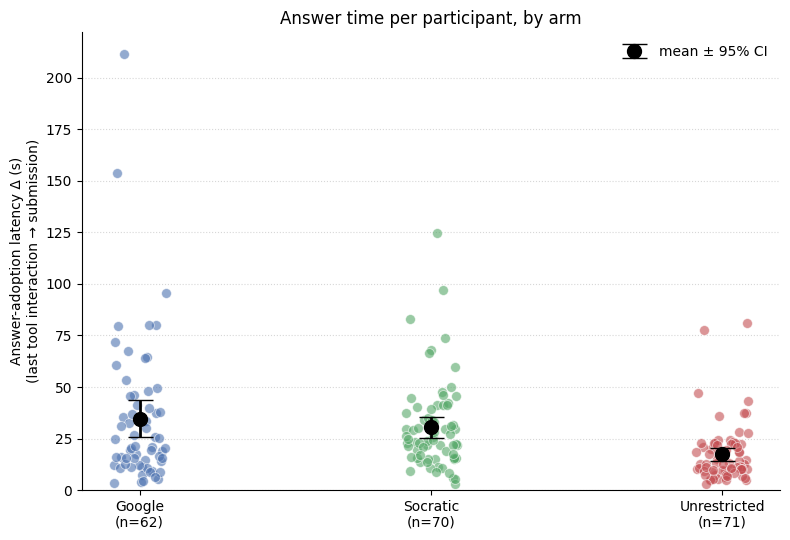

In [11]:
import matplotlib.pyplot as plt
import scipy.stats as st

# per-participant Δ = median of that person's aided-item adoption latencies (robust to within-person spikes)
pp = (items_train.assign(d=pd.to_numeric(items_train["adopt_delta_s"], errors="coerce"))
      .dropna(subset=["d"])
      .groupby(["pid", "arm"], observed=True)["d"].median().rename("delta_s").reset_index())

ARM_ORDER  = ["google", "socratic", "unrestricted"]
ARM_LABELS = {"google": "Google", "socratic": "Socratic", "unrestricted": "Unrestricted"}
COLORS     = {"google": "#4C72B0", "socratic": "#55A868", "unrestricted": "#C44E52"}

rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(8, 5.5))
xticklabels = []
for i, arm in enumerate(ARM_ORDER):
    y = pp.loc[pp.arm == arm, "delta_s"].dropna().values
    x = i + rng.uniform(-0.09, 0.09, len(y))                       # jitter
    ax.scatter(x, y, color=COLORS[arm], alpha=0.6, s=50,
               edgecolor="white", linewidth=0.6, zorder=3)
    n = len(y); m = y.mean()
    if n > 1:
        ci = y.std(ddof=1) / np.sqrt(n) * st.t.ppf(0.975, n - 1)   # 95% t-CI of the mean
        ax.errorbar(i, m, yerr=ci, fmt="o", color="black", ms=10, capsize=9,
                    lw=2, zorder=4, label="mean ± 95% CI" if i == 0 else None)
    xticklabels.append(f"{ARM_LABELS[arm]}\n(n={n})")

ax.set_xticks(range(len(ARM_ORDER)))
ax.set_xticklabels(xticklabels)
ax.set_ylabel("Answer-adoption latency Δ (s)\n(last tool interaction → submission)")
ax.set_title("Answer time per participant, by arm")
ax.set_ylim(bottom=0)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, ls=":", alpha=0.5)
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()


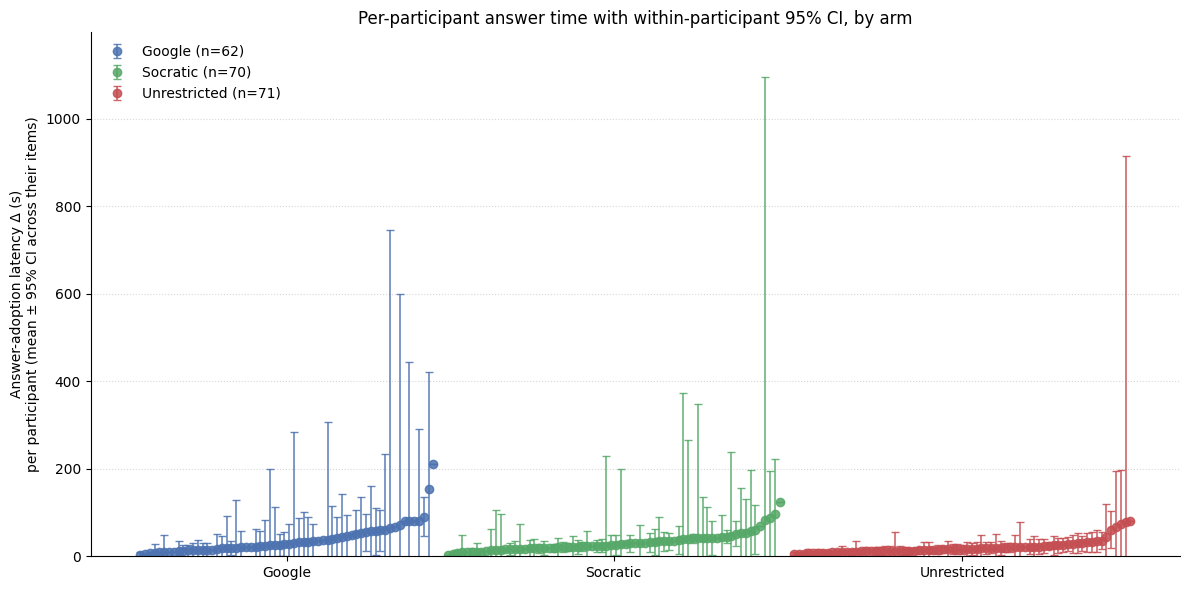

In [12]:
import matplotlib.pyplot as plt
import scipy.stats as st

d = (items_train.assign(d=pd.to_numeric(items_train["adopt_delta_s"], errors="coerce"))
     .dropna(subset=["d"]))

# per-participant mean Δ and 95% t-CI across THAT participant's aided items
def part_ci(x, conf=.95):
    x = x.values; n = len(x); m = x.mean()
    if n < 2:                                        # need >=2 items for a CI
        return pd.Series(dict(n=n, mean=m, lo=np.nan, hi=np.nan))
    se = x.std(ddof=1) / np.sqrt(n); h = se * st.t.ppf(.5 + conf/2, n - 1)
    return pd.Series(dict(n=n, mean=m, lo=m - h, hi=m + h))

pp = (d.groupby(["pid", "arm"], observed=True)["d"].apply(part_ci)
      .unstack().reset_index())

ARM_ORDER  = ["google", "socratic", "unrestricted"]
ARM_LABELS = {"google": "Google", "socratic": "Socratic", "unrestricted": "Unrestricted"}
COLORS     = {"google": "#4C72B0", "socratic": "#55A868", "unrestricted": "#C44E52"}

fig, ax = plt.subplots(figsize=(12, 6))
xpos, centers = 0, []
for arm in ARM_ORDER:
    sub = pp[pp.arm == arm].sort_values("mean").reset_index(drop=True)
    xs = np.arange(len(sub)) + xpos
    lo = sub["lo"].fillna(sub["mean"]); hi = sub["hi"].fillna(sub["mean"])   # n<2 -> no bar
    yerr = np.vstack([sub["mean"] - lo, hi - sub["mean"]])
    ax.errorbar(xs, sub["mean"], yerr=yerr, fmt="o", color=COLORS[arm], ms=6,
                capsize=3, lw=1.2, ecolor=COLORS[arm], alpha=0.85,
                label=f"{ARM_LABELS[arm]} (n={len(sub)})")
    centers.append(xs.mean() if len(xs) else xpos)
    xpos += len(sub) + 2                             # gap between arm blocks

ax.set_xticks(centers); ax.set_xticklabels([ARM_LABELS[a] for a in ARM_ORDER])
ax.set_ylabel("Answer-adoption latency Δ (s)\nper participant (mean ± 95% CI across their items)")
ax.set_title("Per-participant answer time with within-participant 95% CI, by arm")
ax.set_ylim(bottom=0)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, ls=":", alpha=0.5)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()


### 1.9 Early investigation plots

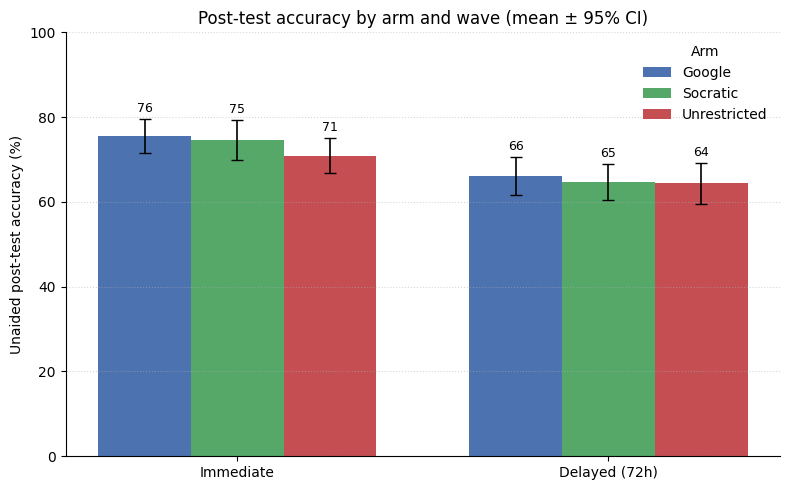

In [13]:
import matplotlib.pyplot as plt
import scipy.stats as st

def _mean_ci(x, conf=0.95):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().values
    n = len(x); m = x.mean() if n else np.nan
    if n < 2: return m, np.nan, np.nan, n
    se = x.std(ddof=1) / np.sqrt(n)
    h = se * st.t.ppf(0.5 + conf/2, n - 1)
    return m, m - h, m + h, n

WAVES = ["immediate", "delayed"]
ARM_LABELS = {"google": "Google", "socratic": "Socratic", "unrestricted": "Unrestricted"}
COLORS = {"google": "#4C72B0", "socratic": "#55A868", "unrestricted": "#C44E52"}

x = np.arange(len(WAVES))
w = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
for i, arm in enumerate(ARM_ORDER):
    means, los, his = [], [], []
    for wave in WAVES:
        sub = acc_pw[(acc_pw.wave == wave) & (acc_pw.arm == arm)]["acc"]
        m, lo, hi, n = _mean_ci(sub)
        means.append(m * 100); los.append((m - lo) * 100); his.append((hi - m) * 100)
    off = (i - 1) * w
    bars = ax.bar(x + off, means, w, label=ARM_LABELS[arm], color=COLORS[arm],
                  yerr=[los, his], capsize=4, error_kw=dict(lw=1.2))
    ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(["Immediate", "Delayed (72h)"])
ax.set_ylabel("Unaided post-test accuracy (%)")
ax.set_title("Post-test accuracy by arm and wave (mean ± 95% CI)")
ax.set_ylim(0, 100)
ax.legend(title="Arm", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, ls=":", alpha=0.5)
fig.tight_layout()
plt.show()


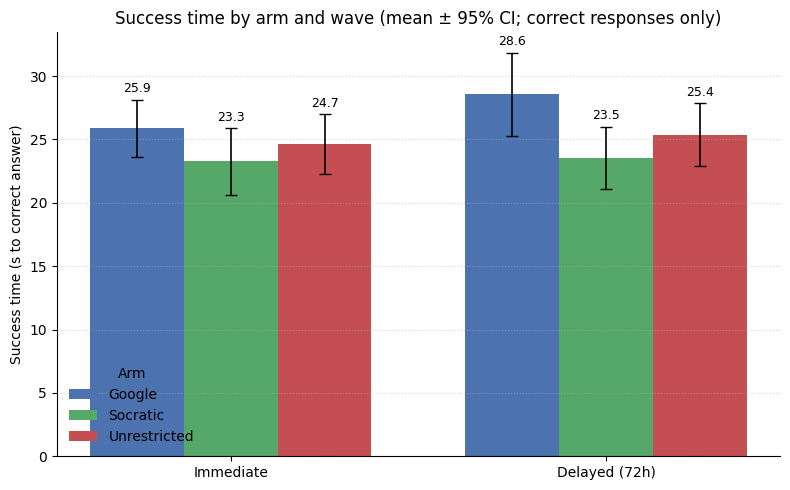

In [14]:
# --- Success-time bar chart (sibling of the accuracy chart above) ---------------
# "Success time" = time to a CORRECT answer. We aggregate per participant x wave the
# mean duration over successful (event==1) items, then plot arm means +/- 95% CI,
# reusing the same grouped-bar layout, colours and helpers as the accuracy figure.

st_ok = surv[surv["event"] == 1].copy()          # successful (correct) items only
st_pw = (st_ok.groupby(["pid", "wave", "arm"], observed=True)["duration_s"]
              .mean().reset_index())              # per participant x wave success time

fig, ax = plt.subplots(figsize=(8, 5))
for i, arm in enumerate(ARM_ORDER):
    means, los, his = [], [], []
    for wave in WAVES:
        sub = st_pw[(st_pw.wave == wave) & (st_pw.arm == arm)]["duration_s"]
        m, lo, hi, n = _mean_ci(sub)
        means.append(m); los.append(m - lo); his.append(hi - m)
    off = (i - 1) * w
    bars = ax.bar(x + off, means, w, label=ARM_LABELS[arm], color=COLORS[arm],
                  yerr=[los, his], capsize=4, error_kw=dict(lw=1.2))
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(["Immediate", "Delayed (72h)"])
ax.set_ylabel("Success time (s to correct answer)")
ax.set_title("Success time by arm and wave (mean ± 95% CI; correct responses only)")
ax.legend(title="Arm", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, ls=":", alpha=0.5)
fig.tight_layout()
plt.show()


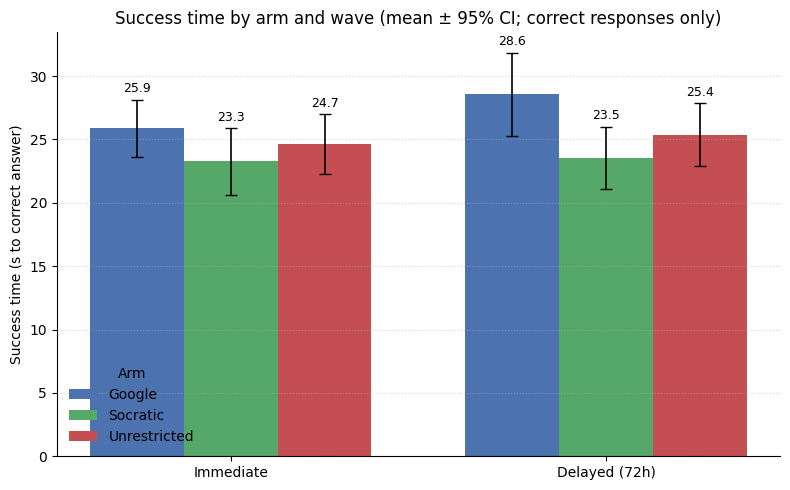

In [15]:
# --- Success-time bar chart (sibling of the accuracy chart above) ---------------
# "Success time" = time to a CORRECT answer. We aggregate per participant x wave the
# mean duration over successful (event==1) items, then plot arm means +/- 95% CI,
# reusing the same grouped-bar layout, colours and helpers as the accuracy figure.

st_ok = surv[surv["event"] == 1].copy()          # successful (correct) items only
st_pw = (st_ok.groupby(["pid", "wave", "arm"], observed=True)["duration_s"]
              .mean().reset_index())              # per participant x wave success time

fig, ax = plt.subplots(figsize=(8, 5))
for i, arm in enumerate(ARM_ORDER):
    means, los, his = [], [], []
    for wave in WAVES:
        sub = st_pw[(st_pw.wave == wave) & (st_pw.arm == arm)]["duration_s"]
        m, lo, hi, n = _mean_ci(sub)
        means.append(m); los.append(m - lo); his.append(hi - m)
    off = (i - 1) * w
    bars = ax.bar(x + off, means, w, label=ARM_LABELS[arm], color=COLORS[arm],
                  yerr=[los, his], capsize=4, error_kw=dict(lw=1.2))
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(["Immediate", "Delayed (72h)"])
ax.set_ylabel("Success time (s to correct answer)")
ax.set_title("Success time by arm and wave (mean ± 95% CI; correct responses only)")
ax.legend(title="Arm", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, ls=":", alpha=0.5)
fig.tight_layout()
plt.show()


Higher-order (Analyze + Evaluate) immediate accuracy (%), by arm
(8 higher-order items/participant)
               n  mean  ci_lo  ci_hi
arm                                 
google        69  69.2   64.3   74.1
socratic      72  69.8   64.2   75.4
unrestricted  77  68.2   63.0   73.4


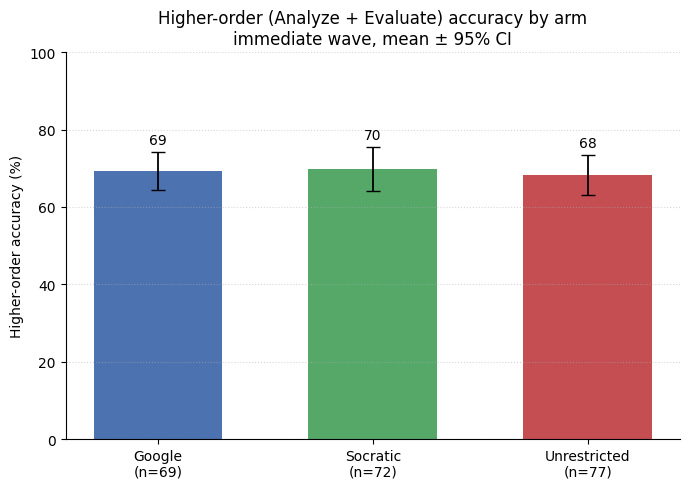

In [16]:
import scipy.stats as st

# higher-order items = Analyze + Evaluate (order == "higher"), immediate wave
hi = unassisted[(unassisted.wave == "immediate") & (unassisted.order == "higher")]

# per-participant accuracy on higher-order items, with arm
acc_hi = (hi.groupby("pid", observed=True)
            .agg(acc_higher=("correct", "mean"), n_items=("correct", "size"))
            .reset_index()
            .merge(covars[["pid", "arm"]], on="pid"))
acc_hi["acc_higher"] = pd.to_numeric(acc_hi["acc_higher"], errors="coerce")  # dtype guard

def mean_ci(x, conf=.95):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().values
    n = len(x); m = x.mean() if n else np.nan
    if n < 2: return pd.Series(dict(n=n, mean=m, ci_lo=np.nan, ci_hi=np.nan))
    se = x.std(ddof=1) / np.sqrt(n); h = se * st.t.ppf(.5 + conf/2, n - 1)
    return pd.Series(dict(n=n, mean=m, ci_lo=m - h, ci_hi=m + h))

tab = (acc_hi.groupby("arm", observed=True)["acc_higher"]
       .apply(mean_ci).unstack().reindex(ARM_ORDER))
for c in ["mean", "ci_lo", "ci_hi"]:
    tab[c] = (tab[c] * 100).round(1)
tab["n"] = tab["n"].astype("Int64")

print(f"Higher-order (Analyze + Evaluate) immediate accuracy (%), by arm")
print(f"({int(acc_hi['n_items'].median())} higher-order items/participant)")
print("=" * 56)
print(tab[["n", "mean", "ci_lo", "ci_hi"]].to_string())

import matplotlib.pyplot as plt
import scipy.stats as st

# higher-order items = Analyze + Evaluate, immediate wave
hi = unassisted[(unassisted.wave == "immediate") & (unassisted.order == "higher")]
acc_hi = (hi.groupby("pid", observed=True)["correct"].mean().rename("acc").reset_index()
            .merge(covars[["pid", "arm"]], on="pid"))
acc_hi["acc"] = pd.to_numeric(acc_hi["acc"], errors="coerce")

ARM_LABELS = {"google": "Google", "socratic": "Socratic", "unrestricted": "Unrestricted"}
COLORS = {"google": "#4C72B0", "socratic": "#55A868", "unrestricted": "#C44E52"}

means, los, his, ns = [], [], [], []
for arm in ARM_ORDER:
    x = acc_hi.loc[acc_hi.arm == arm, "acc"].dropna().values
    n = len(x); m = x.mean()
    se = x.std(ddof=1) / np.sqrt(n) if n > 1 else np.nan
    h = se * st.t.ppf(0.975, n - 1) if n > 1 else np.nan
    means.append(m * 100); los.append(h * 100); his.append(h * 100); ns.append(n)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(range(len(ARM_ORDER)), means, 0.6,
              color=[COLORS[a] for a in ARM_ORDER],
              yerr=[los, his], capsize=5, error_kw=dict(lw=1.3))
ax.bar_label(bars, fmt="%.0f", padding=4, fontsize=10)

ax.set_xticks(range(len(ARM_ORDER)))
ax.set_xticklabels([f"{ARM_LABELS[a]}\n(n={n})" for a, n in zip(ARM_ORDER, ns)])
ax.set_ylabel("Higher-order accuracy (%)")
ax.set_title("Higher-order (Analyze + Evaluate) accuracy by arm\nimmediate wave, mean ± 95% CI")
ax.set_ylim(0, 100)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, ls=":", alpha=0.5)
fig.tight_layout()
plt.show()



In [17]:
import scipy.stats as st

# --- FIX: acc came out as object dtype (empty delayed-wave concat) -> coerce ---
for _c in ["acc", "n_items", "n_correct", "total_time_ms"]:
    if _c in acc_pw:
        acc_pw[_c] = pd.to_numeric(acc_pw[_c], errors="coerce")

ALPHA = globals().get("ALPHA", 0.05)
DELTA = globals().get("DELTA", 0.085)          # NI margin, 0-1 scale = 8.5 pp

# --- Immediate-wave, covariate-adjusted ANCOVA (the estimable primary here) ----
imm = acc_pw[acc_pw.wave == "immediate"].copy()
m = smf.ols("acc ~ socratic + unrestricted + minivlat_c + aiuse_c",
            data=imm).fit(cov_type="HC3")

def contrast(weights, direction=+1):
    L = pd.Series(weights, index=m.params.index).fillna(0.0).values
    est = float(L @ m.params.values)
    se  = float(np.sqrt(L @ m.cov_params().values @ L))
    return est, se, st.norm.cdf(direction * est / se)   # one-sided p

z = st.norm.ppf(1 - ALPHA)
sig = lambda p: "*** SIGNIFICANT ***" if p < ALPHA else "not significant"
print(f"IMMEDIATE ANCOVA (HC3), n = {imm.pid.nunique()} | one-sided alpha = {ALPHA}")
print("=" * 74)

# [1] H1a superiority: Unrestricted - Google (predicted harm, i.e. negative)
est, se, p1 = contrast({"unrestricted": 1}, direction=-1)
print(f"[1] H1a Unrestricted-Google : {est*100:+.2f} pp  "
      f"95%CI[{(est-1.96*se)*100:+.2f},{(est+1.96*se)*100:+.2f}]  "
      f"one-sided p={p1:.4f}  -> {sig(p1)}")

# [2] H2a non-inferiority: Socratic - Google, NI if lower 1-sided 95% bound > -Delta
est2, se2, _ = contrast({"socratic": 1})
lo90 = est2 - z * se2
print(f"[2] H2a Socratic-Google (NI): {est2*100:+.2f} pp  lower90%={lo90*100:+.2f} pp  "
      f"vs -{DELTA*100:.1f} pp  -> {'NON-INFERIOR' if lo90 > -DELTA else 'NI not established'}")

# [3] supporting: Socratic - Unrestricted (predicted positive)
est3, se3, p3 = contrast({"socratic": 1, "unrestricted": -1}, direction=+1)
print(f"[3] Socratic-Unrestricted   : {est3*100:+.2f} pp  one-sided p={p3:.4f}  -> {sig(p3)}")


IMMEDIATE ANCOVA (HC3), n = 218 | one-sided alpha = 0.05
[1] H1a Unrestricted-Google : -5.01 pp  95%CI[-10.37,+0.35]  one-sided p=0.9665  -> not significant
[2] H2a Socratic-Google (NI): -0.66 pp  lower90%=-5.54 pp  vs -8.5 pp  -> NON-INFERIOR
[3] Socratic-Unrestricted   : +4.36 pp  one-sided p=0.9206  -> not significant


## 2. Statistical analysis
### 2.1 Descriptives and baseline table
Baseline characteristics by arm with the maximum pairwise standardised mean difference; per the
SAP (Senn 1994; CONSORT) **no significance tests of baseline balance** are run.

In [18]:
def smd(x, g):
    arms = [pd.to_numeric(x[g == a], errors="coerce").dropna() for a in ARM_ORDER]
    out = 0.0
    for i in range(3):
        for j in range(i + 1, 3):
            a, b = arms[i], arms[j]
            if len(a) > 1 and len(b) > 1:
                sp = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
                if sp > 0: out = max(out, abs(a.mean() - b.mean()) / sp)
    return out

base_vars = ["minivlat_recomputed","aiuse","mails","sgl","confidence","IL_ave","EL_ave","GL_ave"]
base_vars = [v for v in base_vars if v in df and df[v].notna().any()]
tab = df.groupby("arm", observed=True)[base_vars].mean().T.round(2)
tab["max_pairwise_SMD"] = [round(smd(df[v], df["arm"]), 2) for v in base_vars]
print("Participants per arm:", df["arm"].value_counts().reindex(ARM_ORDER).to_dict())
print("(covariates entering models: minivlat_recomputed, aiuse; the rest are descriptive)")
tab

Participants per arm: {'google': 69, 'socratic': 72, 'unrestricted': 77}
(covariates entering models: minivlat_recomputed, aiuse; the rest are descriptive)


arm,google,socratic,unrestricted,max_pairwise_SMD
minivlat_recomputed,7.84,7.61,7.91,0.11
aiuse,3.93,4.12,4.12,0.20
IL_ave,7.19,7.56,7.18,0.19
EL_ave,4.42,5.56,3.89,0.68
GL_ave,5.29,4.70,4.62,0.28


### 2.2 Primary analysis: accuracy (sole primary outcome, D3)
Participant×wave linear mixed model (REML), **`wave_d` a 0/1 dummy (immediate = 0, D2)**, arm
dummies × wave, mean-centred Mini-VLAT and AIUse, participant random intercept:

$$Y_{iw}=\beta_0+\beta_1\mathrm{Soc}_i+\beta_2\mathrm{Unr}_i+\delta\,\mathrm{Wave}_w+\beta_4(\mathrm{Soc}_i\!\times\!\mathrm{Wave}_w)+\beta_5(\mathrm{Unr}_i\!\times\!\mathrm{Wave}_w)+\gamma_1\mathrm{VLAT}^c_i+\gamma_2\mathrm{AIUse}^c_i+u_i+\varepsilon_{iw}$$

β₂ = **immediate** Unrestricted−Google (H1ₐ); β₁ = **immediate** Socratic−Google (H2ₐ);
β₁−β₂ = supporting Socratic−Unrestricted; β₂+β₅ = **delayed** Unrestricted−Google (H5ₐ).
This cell reports the estimates with two-sided 95 % CIs and Hedges *g*; the one-sided
confirmatory decisions are in 2.3.

In [19]:
# fit_primary_acc implements eq:primary-acc (see sap_estimators.py, shared with validation)
res_acc = fit_primary_acc(acc_pw)
def acc_contrast(Ld):
    return lincom(res_acc, Ld)

def hedges_g(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    n1, n2 = len(a), len(b)
    if min(n1, n2) < 2: return np.nan
    sp = np.sqrt(((n1-1)*a.var(ddof=1) + (n2-1)*b.var(ddof=1)) / (n1+n2-2))
    d = (a.mean() - b.mean()) / sp if sp > 0 else np.nan
    return d * (1 - 3 / (4*(n1+n2-2) - 1))

# immediate-wave accuracy per arm, for Hedges g (primary estimand = immediate)
_imm = acc_pw[acc_pw.wave == "immediate"]
CONTRASTS = {
    "immediate  Unrestricted-Google (H1a)": ({"unrestricted": 1}, ("google","unrestricted")),
    "immediate  Socratic-Google (H2a)":     ({"socratic": 1},     ("google","socratic")),
    "immediate  Socratic-Unrestricted (supp)": ({"socratic":1,"unrestricted":-1}, ("unrestricted","socratic")),
    "delayed    Unrestricted-Google (H5a)": ({"unrestricted":1,"unrestricted:wave_d":1}, None),
}
rows = []
for lab, (Ld, gpair) in CONTRASTS.items():
    est, se = acc_contrast(Ld); lo, hi = ci95(est, se)
    g = hedges_g(_imm.loc[_imm.arm==gpair[1],"acc"], _imm.loc[_imm.arm==gpair[0],"acc"]) if gpair else np.nan
    rows.append([lab, est, se, lo, hi, g])
acc_tab = pd.DataFrame(rows, columns=["contrast","est_pp","se","ci95_lo","ci95_hi","hedges_g"]).set_index("contrast")
print(res_acc.summary().tables[1])
print("\nImmediate-anchored accuracy contrasts (proportion scale) with two-sided 95% CIs:")
acc_tab.round(4)

                      Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept             0.756    0.020  37.032  0.000   0.716   0.796
socratic             -0.007    0.029  -0.233  0.816  -0.063   0.049
unrestricted         -0.051    0.028  -1.798  0.072  -0.106   0.005
wave_d               -0.108    0.021  -5.154  0.000  -0.148  -0.067
socratic:wave_d       0.003    0.029   0.090  0.928  -0.055   0.060
unrestricted:wave_d   0.040    0.029   1.394  0.163  -0.016   0.097
minivlat_c            0.023    0.004   5.806  0.000   0.015   0.031
aiuse_c               0.016    0.010   1.521  0.128  -0.005   0.036
Group Var             0.016    0.031                               

Immediate-anchored accuracy contrasts (proportion scale) with two-sided 95% CIs:


,est_pp,se,ci95_lo,ci95_hi,hedges_g
contrast,,,,,
immediate Unrestricted-Google (H1a),-0.0506,0.0281,-0.1057,0.0045,-0.2647
immediate Socratic-Google (H2a),-0.0067,0.0286,-0.0627,0.0494,-0.0485
immediate Socratic-Unrestricted (supp),0.0439,0.0278,-0.0105,0.0984,0.1944
delayed Unrestricted-Google (H5a),-0.0102,0.0305,-0.0701,0.0496,NaN


### 2.3 Confirmatory family — fixed-sequence gatekeeper (D3, D6)
Full α = 0.05, one-sided, tested in order; testing **stops at the first non-rejection**.
**(1)** H1ₐ superiority β₂<0 → **(2)** H2ₐ non-inferiority (90 % CI lower bound for β₁ > −Δ,
Δ = 8.5 pp), required in **ITT ∧ per-protocol** → **(3)** supporting β₁−β₂>0.

In [20]:
# gatekeeper() (sap_estimators.py) estimates all three contrasts unconditionally (SAP:
# quantities beyond a closed gate are still reported as estimates with CIs); the fixed
# SEQUENCE governs only the confirmatory verdicts. Shared verbatim with the validation.
pp_ids = set(aided.loc[aided.engaged == 1, "pid"])
gk = gatekeeper(acc_pw, pp_ids, alpha=ALPHA, delta=DELTA, res=res_acc)

gate2 = "tested" if gk["rej_h1a"] else "GATE CLOSED (estimate only)"
gate3 = "tested" if gk["ni_declared"] else "GATE CLOSED (estimate only)"
print("FIXED-SEQUENCE GATEKEEPER (one-sided alpha = %.3f, NI margin Delta = %.3f pp on 0-1 scale)"
      % (ALPHA, DELTA)); print("=" * 78)
lo, hi = gk["ci95_b2"]
print(f"[1] H1a superiority  Unrestricted-Google (imm)  est={gk['b2']:+.4f} 95%CI[{lo:+.4f},{hi:+.4f}] "
      f"p1={gk['p_h1a']:.4f} -> {'REJECT H0 (harm supported)' if gk['rej_h1a'] else 'not rejected -> gate closes'}")
lo, hi = gk["ci95_b1"]
print(f"[2] H2a non-inferiority  Socratic-Google (imm)  est={gk['b1']:+.4f} 95%CI[{lo:+.4f},{hi:+.4f}]  [{gate2}]")
print(f"        ITT 90%CI lower={gk['lo90_itt']:+.4f} vs -Delta={-DELTA:+.4f}  NI p={gk['p_ni_itt']:.4f} -> {'PASS' if gk['ni_itt'] else 'fail'}")
print(f"        PP  90%CI lower={gk['lo90_pp']:+.4f} (n_PP={gk['n_pp']}) -> {'PASS' if gk['ni_pp'] else ('fail' if gk['ni_pp'] is False else 'n/a')}")
print(f"        verdict: H2a non-inferiority {'DECLARED (ITT & PP)' if gk['ni_declared'] else 'not declared'}")
lo, hi = gk["ci95_bs"]
print(f"[3] supporting  Socratic-Unrestricted (imm)     est={gk['bs']:+.4f} 95%CI[{lo:+.4f},{hi:+.4f}] "
      f"p={gk['p_sup']:.4f} -> {'REJECT (scaffold superior)' if gk['rej_sup'] else 'not rejected'}  [{gate3}]")
print("\n(Dummy data has no true effect, so step 1 does not reject; steps 2-3 are computed and shown"
      "\n as estimates to validate the NI/TOST + per-protocol machinery every run.)")

FIXED-SEQUENCE GATEKEEPER (one-sided alpha = 0.050, NI margin Delta = 0.085 pp on 0-1 scale)
[1] H1a superiority  Unrestricted-Google (imm)  est=-0.0506 95%CI[-0.1057,+0.0045] p1=0.0361 -> REJECT H0 (harm supported)
[2] H2a non-inferiority  Socratic-Google (imm)  est=-0.0067 95%CI[-0.0627,+0.0494]  [tested]
        ITT 90%CI lower=-0.0537 vs -Delta=-0.0850  NI p=0.0031 -> PASS
        PP  90%CI lower=-0.0497 (n_PP=203) -> PASS
        verdict: H2a non-inferiority DECLARED (ITT & PP)
[3] supporting  Socratic-Unrestricted (imm)     est=+0.0439 95%CI[-0.0105,+0.0984] p=0.0569 -> not rejected  [tested]

(Dummy data has no true effect, so step 1 does not reject; steps 2-3 are computed and shown
 as estimates to validate the NI/TOST + per-protocol machinery every run.)


### 2.4 Key secondary: success time — wave-stratified Cox with arm×wave (D9-R2)
Item-level Cox; event = correct answer, incorrect/IDK/timeout right-censored; **stratified by
wave** (own baseline hazard) **with arm×wave interaction terms**; participant-clustered robust SE.
θ₂ = immediate Unrestricted−Google log-HR (H1_b, one-sided); θ₁−θ₂ = supporting H2_b; delayed
combinations = exploratory H5_b (estimates + CIs only). PH checked (Grambsch–Therneau); log-normal
AFT is the pre-specified fallback, now with **participant-level cluster-bootstrap inference** (fix
2026-07-16: lifelines AFT fitters have no `cluster_col`, so the earlier naive fit treated each
participant's ~16 items per wave as independent — anticonservative p-values; point estimates
unchanged). HR > 1 = faster correct production.

In [21]:
# fit_cox_st implements eq:primary-st (see sap_estimators.py, shared with validation)
cph = fit_cox_st(surv)
d = surv.dropna(subset=["duration_s","event","socratic","unrestricted","minivlat_c","aiuse_c"]).copy()
def cox_contrast(Ld):
    return cox_lincom(cph, Ld)

st_rows = []
for lab, Ld, direction, conf in [
    ("immediate Unrestricted-Google (H1b)", {"unrestricted":1}, -1, True),
    ("immediate Socratic-Google",           {"socratic":1},      0, False),
    ("immediate Socratic-Unrestricted (H2b supp)", {"socratic":1,"unrestricted":-1}, +1, True),
    ("delayed   Unrestricted-Google (H5b expl)", {"unrestricted":1,"unr_wave":1}, 0, False),
    ("delayed   Socratic-Google (H5b expl)",     {"socratic":1,"soc_wave":1},     0, False),
]:
    est, se = cox_contrast(Ld); lo, hi = ci95(est, se)
    p = z_onesided_p(est, se, direction) if direction else np.nan
    st_rows.append([lab, np.exp(est), np.exp(lo), np.exp(hi), (p if conf else np.nan)])
st_tab = pd.DataFrame(st_rows, columns=["contrast","HR","HR_ci95_lo","HR_ci95_hi","one_sided_p"]).set_index("contrast")
# key-secondary success-time family = its own one-sided Holm (supporting evidence only, D9/SAP)
_conf = st_tab["one_sided_p"].dropna()
st_tab.loc[_conf.index, "p_holm"] = multipletests(_conf.values, alpha=ALPHA, method="holm")[1]
print("Success-time contrasts (HR), participant-clustered Cox, arm x wave (own Holm family):")
print(st_tab.round(4).to_string())

try:
    ph = proportional_hazard_test(cph, d, time_transform="rank")
    arm_ph = ph.summary.loc[ph.summary.index.isin(["socratic","unrestricted"]), ["test_statistic","p"]]
    print("\nPH test (arm terms):"); print(arm_ph.round(3).to_string())
    if (arm_ph["p"] < 0.05).any():
        # FIX 2026-07-16 (additive): lifelines AFT fitters have no cluster_col, so the earlier
        # naive LogNormalAFTFitter().fit() treated each participant's clustered items as
        # independent -> anticonservative SEs/p-values (same failure mode the Monte Carlo
        # validation caught on the Cox side, D10). Point estimates are unchanged; inference now
        # comes from a participant-level cluster bootstrap (pids resampled with replacement
        # within arm, refit per replicate, percentile 95% CIs + two-sided sign-flip p) via
        # sap_estimators.fit_aft_fallback. p_naive is kept only to document the correction.
        print("  PH violated -> log-normal AFT fallback (time ratios), "
              "participant-cluster bootstrap inference:")
        aft_fb = fit_aft_fallback(d, n_boot=1000, seed=CONFIG["SEED"])
        aft = aft_fb["aft"]          # point fit identical to the previous naive call
        print(aft_fb["table"].round(3).to_string())
        print(f"  bootstrap: {aft_fb['n_ok']}/{aft_fb['n_boot']} refits converged "
              f"(seed {aft_fb['seed']}); percentile CIs; p_boot = two-sided sign-flip (r+1)/(B+1).")
except Exception as e:
    print("PH test not computable on this sample:", type(e).__name__)

Success-time contrasts (HR), participant-clustered Cox, arm x wave (own Holm family):
                                                HR  HR_ci95_lo  HR_ci95_hi  one_sided_p  p_holm
contrast                                                                                       
immediate Unrestricted-Google (H1b)         1.0221      0.8695      1.2015       0.6044  0.6044
immediate Socratic-Google                   1.1655      1.0059      1.3504          NaN     NaN
immediate Socratic-Unrestricted (H2b supp)  1.1403      0.9682      1.3431       0.0579  0.1158
delayed   Unrestricted-Google (H5b expl)    1.1322      0.9386      1.3658          NaN     NaN
delayed   Socratic-Google (H5b expl)        1.1993      0.9916      1.4506          NaN     NaN

PH test (arm terms):
              test_statistic      p
socratic               0.599  0.439
unrestricted           0.004  0.950


### 2.5 Secondary confirmatory I: Bloom-level concentration (H4ₐ)
**Primary:** binary lower/higher-order × arm interaction on the **immediate** post-test, item
level (8 items/side). Focal term = Unrestricted × higher-order; H4ₐ is one-sided (β₅<0 = deficit
larger at higher order). The confirmatory one-sided *p* comes from a participant-clustered logistic
GEE (robust); the SAP's crossed-random-effects Bayesian GLMM is reported as corroboration, and the
interaction is also expressed as an average marginal interaction contrast on the probability scale.

In [22]:
ub = surv[(surv["wave"] == "immediate") & surv["order"].notna()].copy()
ub["order_hi"] = (ub["order"] == "higher").astype(int)
print("Immediate accuracy by arm x order:")
print(ub.pivot_table(index="order", columns="arm", values="correct", observed=True).round(2).to_string())

# confirmatory one-sided p: participant-clustered logistic GEE (sap_estimators.py)
gee = fit_bloom_gee(ub)
b5, se5, p_h4a = h4a_from_gee(gee)                  # H1: b5 < 0
lo, hi = ci95(b5, se5)
print(f"\nH4a focal interaction (Unrestricted x higher-order), log-odds: est={b5:+.4f} "
      f"95%CI[{lo:+.4f},{hi:+.4f}] one-sided p={p_h4a:.4f}")

# average marginal interaction contrast on the probability scale
def _pred(dfx): return gee.predict(dfx)
base = ub.copy()
def setarm(a):
    x = base.copy(); x["socratic"]=int(a=="socratic"); x["unrestricted"]=int(a=="unrestricted"); return x
amic_rows = {}
for a in ["google","unrestricted","socratic"]:
    xa = setarm(a); xhi = xa.copy(); xhi["order_hi"]=1; xlo = xa.copy(); xlo["order_hi"]=0
    amic_rows[a] = float(_pred(xhi).mean() - _pred(xlo).mean())
amic = amic_rows["unrestricted"] - amic_rows["google"]
print(f"AMIC (probability scale) Unrestricted-vs-Google hi-minus-lo difference-in-differences = {amic:+.4f}")

# SAP-specified crossed-random-effects Bayesian GLMM (corroboration; VB SDs are anticonservative)
try:
    from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
    bm = BinomialBayesMixedGLM.from_formula(
        "correct ~ (socratic + unrestricted) * order_hi + minivlat_c + aiuse_c",
        {"pid": "0 + C(pid)", "item": "0 + C(item_id)"}, ub).fit_vb()
    sd = pd.Series(np.asarray(bm.fe_sd), index=bm.model.exog_names)  # VB posterior SDs (cov_params() is a vector under fit_vb)
    fe = pd.DataFrame({"post_mean": bm.fe_mean, "post_sd": sd})
    print("\nCrossed-RE Bayesian GLMM (SAP-specified, corroboration only):")
    print(fe[fe.index.str.contains(":")].round(3).to_string())
except Exception as e:
    print("\nCrossed-RE VB GLMM not computable on this sample:", type(e).__name__)

Immediate accuracy by arm x order:
arm     google  socratic  unrestricted
order                                 
higher    0.69       0.7          0.68
lower     0.82       0.8          0.74



H4a focal interaction (Unrestricted x higher-order), log-odds: est=+0.4404 95%CI[+0.0515,+0.8292] one-sided p=0.9868
AMIC (probability scale) Unrestricted-vs-Google hi-minus-lo difference-in-differences = +0.0718



Crossed-RE Bayesian GLMM (SAP-specified, corroboration only):
                       post_mean  post_sd
socratic:order_hi          0.184    0.101
unrestricted:order_hi      0.514    0.095


### 2.6 Secondary confirmatory II: persistence (H5ₐ, D9-R1)
Persistence is the **delayed-wave simple effect β₂+β₅** (one-sided, H1: <0) — *not* the
interaction β₅ alone, which only measures decay and is reported with its CI.
Success-time persistence (H5_b) is the exploratory read from 2.4 (estimates + CIs, no verdict).

In [23]:
b5a, se5a, p_h5a = h5a_simple_effect(res_acc)   # delayed U-G simple effect (sap_estimators.py)
lo, hi = ci95(b5a, se5a)
print(f"H5a delayed-wave Unrestricted-Google simple effect (beta2+beta5): est={b5a:+.4f} "
      f"95%CI[{lo:+.4f},{hi:+.4f}] one-sided p={p_h5a:.4f}")
bi, sei = acc_contrast({"unrestricted:wave_d": 1})
lo, hi = ci95(bi, sei)
print(f"  decay estimate beta5 (interaction, CI only): est={bi:+.4f} 95%CI[{lo:+.4f},{hi:+.4f}]")

H5a delayed-wave Unrestricted-Google simple effect (beta2+beta5): est=-0.0102 95%CI[-0.0701,+0.0496] one-sided p=0.3685
  decay estimate beta5 (interaction, CI only): est=+0.0403 95%CI[-0.0164,+0.0971]


### 2.7 Secondary confirmatory family — Holm across {H4ₐ, H5ₐ}
The two secondary confirmatory accuracy hypotheses form one Holm family, one-sided at
familywise α = 0.05 (separate from the primary gatekeeper and from the success-time family).

In [24]:
fam = holm_family({"H4a Bloom concentration (immediate)": p_h4a,
                   "H5a persistence (delayed simple effect)": p_h5a}, alpha=ALPHA)
print("Secondary confirmatory family (one-sided Holm, alpha = %.2f):" % ALPHA)
print(fam.round(4).to_string())

Secondary confirmatory family (one-sided Holm, alpha = 0.05):
                                         one_sided_p  p_holm  reject
H4a Bloom concentration (immediate)           0.9868  0.9868   False
H5a persistence (delayed simple effect)       0.3685  0.7370   False


### 2.8 Productivity (aided block, H3) — BH-FDR
Assisted-side of the trade-off: aided accuracy, log time-per-item, log rate-correct-score, and
the aided success-time Cox. Converging indicators, controlled at a false discovery rate (BH),
one-sided H3 (H0: β₂≤0). Doubles as the affordance manipulation check.

In [25]:
prod_rows = []
for dv in ["aided_acc", "log_time_per_item", "log_rcs"]:
    r = smf.ols(f"{dv} ~ socratic + unrestricted + minivlat_c + aiuse_c", data=aided).fit(cov_type="HC3")
    for arm_d in ["unrestricted", "socratic"]:
        est = float(r.params[arm_d])
        # H3a expects >0 for accuracy/rcs (more/faster); time-per-item expected <0 (less time)
        direction = -1 if dv == "log_time_per_item" else +1
        prod_rows.append(dict(outcome=dv, contrast=f"{arm_d}-google", est=est,
                              p=z_onesided_p(est, float(r.bse[arm_d]), direction)))

ev_arm = aided_surv.groupby("arm", observed=True)["event"].sum().reindex(ARM_ORDER)
if (ev_arm > 0).all():
    # fit_cox_st attaches the full cluster-robust covariance; cox_lincom uses it
    # (variance_matrix_ alone is NAIVE under cluster_col -- see sap_estimators docstring)
    ca = fit_cox_st(aided_surv, formula="socratic + unrestricted + minivlat_c + aiuse_c", strata=None)
    for arm_d in ["unrestricted","socratic"]:
        est, se = cox_lincom(ca, {arm_d: 1})
        prod_rows.append(dict(outcome="aided success (logHR)", contrast=f"{arm_d}-google",
                              est=est, p=z_onesided_p(est, se, +1)))
else:
    print("Aided Cox skipped (arm with zero events on dummy key).")

prod = pd.DataFrame(prod_rows)
prod["p_BH"] = multipletests(prod["p"], alpha=0.05, method="fdr_bh")[1]
print("Arm means on productivity outcomes:")
print(aided.groupby("arm", observed=True)[["aided_acc","rcs","log_time_per_item"]].mean().round(3).to_string())
print("\nProductivity family (one-sided, BH-FDR q=.05):")
print(prod.round(4).to_string())

Arm means on productivity outcomes:
              aided_acc    rcs  log_time_per_item
arm                                              
google            0.638  0.854             10.827
socratic          0.597  0.808             10.946
unrestricted      0.747  1.003             10.817

Productivity family (one-sided, BH-FDR q=.05):
                 outcome             contrast     est       p    p_BH
0              aided_acc  unrestricted-google  0.1069  0.0000  0.0001
1              aided_acc      socratic-google -0.0350  0.8545  0.9766
2      log_time_per_item  unrestricted-google -0.0220  0.4033  0.8066
3      log_time_per_item      socratic-google  0.1058  0.8322  0.9766
4                log_rcs  unrestricted-google  0.2530  0.0244  0.0650
5                log_rcs      socratic-google -0.1564  0.8484  0.9766
6  aided success (logHR)  unrestricted-google  0.1909  0.0116  0.0464
7  aided success (logHR)      socratic-google -0.2051  0.9822  0.9822


### 2.9 Exploratory moderation — prior knowledge × outsourcing (worked-example paradox)
Arm × baseline **continuous** Mini-VLAT on the **immediate** accuracy deficit. Exploratory: joins
no confirmatory family, reported as an estimate with a 95 % CI, **no directional verdict**
(a deficit growing with prior skill would implicate the expertise-reversal / redundancy account).

In [26]:
imm = acc_pw[acc_pw.wave == "immediate"].copy()
mod = smf.ols("acc ~ (socratic + unrestricted) * minivlat_c + aiuse_c", data=imm).fit(cov_type="HC3")
for term in ["unrestricted:minivlat_c", "socratic:minivlat_c"]:
    est = float(mod.params[term]); lo, hi = ci95(est, float(mod.bse[term]))
    print(f"{term:26s}  est={est:+.4f}  95%CI[{lo:+.4f}, {hi:+.4f}]  (exploratory, no verdict)")
print("Negative Unrestricted×MiniVLAT = deficit grows with prior visualisation literacy.")

unrestricted:minivlat_c     est=-0.0151  95%CI[-0.0427, +0.0126]  (exploratory, no verdict)
socratic:minivlat_c         est=-0.0126  95%CI[-0.0413, +0.0161]  (exploratory, no verdict)
Negative Unrestricted×MiniVLAT = deficit grows with prior visualisation literacy.


### 2.10 Robustness analyses (SAP order; immediate-anchored)

In [27]:
print("R1. Unadjusted immediate difference in means + unadjusted Cox")
for a1, a2 in [("google","unrestricted"), ("google","socratic"), ("socratic","unrestricted")]:
    x, y = _imm.loc[_imm.arm==a1,"acc"], _imm.loc[_imm.arm==a2,"acc"]
    if min(len(x), len(y)) >= 2:
        t, p = st.ttest_ind(y, x, equal_var=False)
        print(f"   {a2}-{a1}: diff={y.mean()-x.mean():+.3f}  Welch p={p:.3f}")
cu = fit_cox_st(surv, formula="socratic + unrestricted")
print("   unadjusted Cox HR:", {k: round(float(np.exp(v)),3) for k,v in cu.params_.items()})

R1. Unadjusted immediate difference in means + unadjusted Cox
   unrestricted-google: diff=-0.046  Welch p=0.109
   socratic-google: diff=-0.009  Welch p=0.772
   unrestricted-socratic: diff=-0.037  Welch p=0.237


   unadjusted Cox HR: {'socratic': 1.166, 'unrestricted': 1.075}


In [28]:
print("R2. Lin (2013) fully interacted estimator, per wave (HC3)")
for w in ["immediate","delayed"]:
    dd = acc_pw[acc_pw.wave == w]
    if dd["pid"].nunique() < 6: continue
    r = smf.ols("acc ~ (socratic + unrestricted) * (minivlat_c + aiuse_c)", data=dd).fit(cov_type="HC3")
    print(f"   {w}: unrestricted={r.params['unrestricted']:+.3f} (p={r.pvalues['unrestricted']:.3f}), "
          f"socratic={r.params['socratic']:+.3f} (p={r.pvalues['socratic']:.3f})")

print("\nR3. Fractional logit (Papke-Wooldridge QMLE), per wave, AME")
for w in ["immediate","delayed"]:
    dd = acc_pw[acc_pw.wave == w].copy()
    X = sm.add_constant(dd[["socratic","unrestricted","minivlat_c","aiuse_c"]].astype(float))
    g = sm.GLM(dd["acc"].astype(float), X, family=sm.families.Binomial()).fit(cov_type="HC3")
    ame = {}
    for arm_d in ["socratic","unrestricted"]:
        X1, X0 = X.copy(), X.copy(); other = "unrestricted" if arm_d=="socratic" else "socratic"
        X1[arm_d], X1[other] = 1.0, 0.0; X0[arm_d], X0[other] = 0.0, 0.0
        ame[arm_d] = float(np.mean(g.predict(X1) - g.predict(X0)))
    print(f"   {w}: AME unrestricted={ame['unrestricted']:+.3f} (p={g.pvalues['unrestricted']:.3f}), "
          f"AME socratic={ame['socratic']:+.3f} (p={g.pvalues['socratic']:.3f})")

R2. Lin (2013) fully interacted estimator, per wave (HC3)
   immediate: unrestricted=-0.050 (p=0.075), socratic=-0.007 (p=0.818)
   delayed: unrestricted=-0.016 (p=0.632), socratic=-0.014 (p=0.649)

R3. Fractional logit (Papke-Wooldridge QMLE), per wave, AME
   immediate: AME unrestricted=-0.050 (p=0.063), AME socratic=-0.006 (p=0.833)
   delayed: AME unrestricted=-0.015 (p=0.613), AME socratic=-0.016 (p=0.587)


In [29]:
print("R4. Item-level crossed-random-effects accuracy model (immediate), arm main effects")
_ui = surv[(surv.wave=="immediate") & surv.item_id.notna()].copy()
try:
    gee4 = smf.gee("correct ~ socratic + unrestricted + minivlat_c + aiuse_c",
                   groups="pid", data=_ui, family=sm.families.Binomial(),
                   cov_struct=sm.cov_struct.Exchangeable()).fit()
    print("   GEE(participant-clustered) log-odds:",
          {k: round(float(gee4.params[k]),3) for k in ["socratic","unrestricted"]})
except Exception as e:
    print("   crossed model not computable on this sample:", type(e).__name__)

print(f"\nR5. Randomisation inference on the IMMEDIATE estimands ({CONFIG['N_PERMUTATIONS']} perms)")
def immediate_stats(arm_map):
    di = _imm.copy(); di["arm"] = di["pid"].map(arm_map)
    di["soc"]=(di.arm=="socratic").astype(int); di["unr"]=(di.arm=="unrestricted").astype(int)
    a = smf.ols("acc ~ soc + unr + minivlat_c + aiuse_c", data=di).fit().params["unr"]
    si = surv[surv.wave=="immediate"].copy(); si["arm"]=si["pid"].map(arm_map)
    si["socratic"]=(si.arm=="socratic").astype(int); si["unrestricted"]=(si.arm=="unrestricted").astype(int)
    c = CoxPHFitter().fit(si[["duration_s","event","socratic","unrestricted","minivlat_c","aiuse_c"]],
                          "duration_s","event", formula="socratic + unrestricted + minivlat_c + aiuse_c")
    return a, float(c.params_["unrestricted"])
true_map = dict(zip(covars["pid"], covars["arm"].astype(str)))
obs_a, obs_c = immediate_stats(true_map)
pids, labels = list(true_map), np.array(list(true_map.values()))
pa, pc = [], []
for _ in range(CONFIG["N_PERMUTATIONS"]):
    pm = dict(zip(pids, rng.permutation(labels)))
    try: a, c = immediate_stats(pm); pa.append(a); pc.append(c)
    except Exception: continue
print(f"   accuracy immediate U-G beta={obs_a:+.3f}  RI p={(np.sum(np.abs(pa)>=abs(obs_a))+1)/(len(pa)+1):.3f}")
print(f"   success  immediate U-G logHR={obs_c:+.3f}  RI p={(np.sum(np.abs(pc)>=abs(obs_c))+1)/(len(pc)+1):.3f}")

R4. Item-level crossed-random-effects accuracy model (immediate), arm main effects
   GEE(participant-clustered) log-odds: {'socratic': -0.033, 'unrestricted': -0.259}

R5. Randomisation inference on the IMMEDIATE estimands (2000 perms)


   accuracy immediate U-G beta=-0.050  RI p=0.089
   success  immediate U-G logHR=+0.025  RI p=0.765


In [30]:
print("R6. IDK scoring sensitivity (immediate accuracy contrasts)")
if CONFIG["IDK_OPTION"] is None:
    print("   IDK_OPTION not configured; success time is invariant (IDK censored either way).")
else:
    att = unassisted[~unassisted["idk"]]
    alt = (att.groupby(["pid","wave"], observed=True)["correct"].mean().rename("acc").reset_index()
           .merge(covars, on="pid")); alt["wave_d"] = (alt["wave"]=="delayed").astype(int)
    ra = fit_primary_acc(alt); n2 = list(ra.params.index)
    for lab, Ld in [("U-G", {"unrestricted":1}), ("S-G", {"socratic":1})]:
        L = pd.Series(Ld, index=n2).fillna(0).values
        est = float(L @ ra.params.values); se = float(np.sqrt(L @ ra.cov_params().values @ L))
        print(f"   IDK-excluded immediate {lab}: est={est:+.4f} (p1={st.norm.cdf(est/se):.3f})")

print(f"\nR8. Speeder + attention exclusion (n speeders = {len(speeders)})")
keep = acc_pw[~acc_pw["pid"].isin(speeders)]
if keep["pid"].nunique() >= 6 and keep["arm"].nunique() == 3:
    rk = fit_primary_acc(keep); nk = list(rk.params.index)
    L = pd.Series({"unrestricted":1}, index=nk).fillna(0).values
    est = float(L @ rk.params.values); se = float(np.sqrt(L @ rk.cov_params().values @ L))
    print(f"   immediate U-G after exclusion: est={est:+.4f} (one-sided p={st.norm.cdf(est/se):.3f})")
else:
    print("   too few participants remain on dummy data after exclusion.")

R6. IDK scoring sensitivity (immediate accuracy contrasts)


   IDK-excluded immediate U-G: est=-0.0157 (p1=0.277)
   IDK-excluded immediate S-G: est=-0.0010 (p1=0.486)

R8. Speeder + attention exclusion (n speeders = 0)


   immediate U-G after exclusion: est=-0.0506 (one-sided p=0.036)


### 2.11 Compliance, contamination, complier effects
Compliance = ≥1 tool interaction during training. CACE via Wald/2SLS with assignment as the
instrument. Contamination screen flags Google-arm queries mentioning an LLM.

In [31]:
comp = aided[["pid","arm","engaged"]].merge(pooled[["pid","acc"]], on="pid", how="inner")
print("Compliance (>=1 assigned-tool interaction) by arm:")
print(comp.groupby("arm", observed=True)["engaged"].mean().round(2).to_string())
# One-sided noncompliance Wald/IV: the instrumented exposure is use of the ASSIGNED LLM
# tool, which is structurally zero in the Google arm (it has no LLM). First stage is
# therefore the treated arm's engagement rate, not a cross-arm engagement difference
# (which is near zero when both arms use their own tools and explodes the ratio) -- fix
# validated by simulation (SAP validation notebook, Check 8).
for a1, a2 in [("google","unrestricted"), ("google","socratic")]:
    dd = comp[comp.arm.isin([a1, a2])]; z = (dd.arm == a2).astype(int)
    itt = dd.acc[z==1].mean() - dd.acc[z==0].mean()
    first = dd.engaged[z==1].mean()
    cace = itt/first if first > 1e-9 else np.nan
    print(f"  {a2} vs {a1}: ITT={itt:+.3f}  first-stage (treated engagement)={first:+.2f}  "
          f"CACE={'undefined (no compliance)' if np.isnan(cace) else f'{cace:+.3f}'}")
llm_terms = ("chatgpt","gpt","claude","gemini","copilot","llm"," ai ")
q_all = [q.lower() for qs in items_train["queries"] for q in qs]
hits = [q for q in q_all if any(t in f" {q} " for t in llm_terms)]
print(f"\nContamination screen: {len(hits)}/{len(q_all)} Google-arm queries mention an LLM tool")

Compliance (>=1 assigned-tool interaction) by arm:
arm
google          0.90
socratic        0.97
unrestricted    0.92
  unrestricted vs google: ITT=-0.027  first-stage (treated engagement)=+0.92  CACE=-0.029
  socratic vs google: ITT=-0.003  first-stage (treated engagement)=+0.97  CACE=-0.004

Contamination screen: 0/227 Google-arm queries mention an LLM tool


### 2.12 Attrition, multiple imputation, Lee bounds
CONSORT denominators (all randomised); differential-dropout logit; MICE sensitivity for the
delayed wave; **two-sided** Lee bounds (trims whichever arm responded more).

In [32]:
rand = raw.copy()
rand["pid"] = rand.get("Participant_ID", rand["ResponseId"]).fillna(rand["ResponseId"]).astype(str)
a = rand["arm"].astype(str).str.strip().str.lower().replace({"nan": np.nan})
a = a.mask(a.isna() & rand["Condition"].astype(str).str.upper().eq("SEARCH"), "google")
rand["arm"] = pd.Categorical(a, ARM_ORDER, ordered=True)
rand = rand.dropna(subset=["arm"]).drop_duplicates("pid")[["pid","arm"]]
rand["socratic"]=(rand.arm=="socratic").astype(int); rand["unrestricted"]=(rand.arm=="unrestricted").astype(int)
have_imm, have_del = set(items_immediate["pid"]), set(items_delayed["pid"])
att = rand.copy(); att["immediate"]=att.pid.isin(have_imm).astype(int); att["delayed"]=att.pid.isin(have_del).astype(int)
print(f"Randomised (CONSORT denominator): {len(att)} | completion by arm:")
print(att.groupby("arm", observed=True)[["immediate","delayed"]].mean().round(2).to_string())
try:
    lg = smf.logit("delayed ~ socratic + unrestricted", data=att[att.immediate==1]).fit(disp=0)
    print("\nDifferential-dropout logit (delayed | completed immediate):")
    print(lg.params.round(3).to_string())
except Exception as e:
    print("\nDropout logit not estimable on dummy data:", type(e).__name__)

try:
    from statsmodels.imputation import mice
    wide = (acc_pw.pivot_table(index="pid", columns="wave", values="acc", observed=True)
            .reindex(covars["pid"]).reset_index()
            .merge(covars[["pid","socratic","unrestricted","minivlat_c","aiuse_c"]], on="pid"))
    imp = mice.MICEData(wide.drop(columns="pid").astype(float))
    fit = mice.MICE("delayed ~ socratic + unrestricted + minivlat_c + aiuse_c", sm.OLS, imp).fit(CONFIG["N_MICE"], CONFIG["N_MICE"])
    print(f"\nMICE (m={CONFIG['N_MICE']}; set 50 for real run) pooled delayed-accuracy:")
    print(fit.summary().tables[1])
except Exception as e:
    print(f"\nMICE not estimable on dummy data ({type(e).__name__}).")

# lee_bounds imported from sap_estimators.py (two-sided: trims whichever arm responded more)
d_del = acc_pw[acc_pw.wave == "delayed"]; n_rand = rand["arm"].value_counts()
yu = d_del.loc[d_del.arm=="unrestricted","acc"].values; yg = d_del.loc[d_del.arm=="google","acc"].values
lo, hi = lee_bounds(yu, int(n_rand.get("unrestricted",1)), yg, int(n_rand.get("google",1)))
print(f"\nLee bounds, delayed accuracy, unrestricted-google: [{lo:+.3f}, {hi:+.3f}]"
      if np.isfinite(lo) else "\nLee bounds not computable on dummy data.")

Randomised (CONSORT denominator): 234 | completion by arm:
              immediate  delayed
arm                             
google              0.0      0.0
socratic            0.0      0.0
unrestricted        0.0      0.0

Dropout logit not estimable on dummy data: ValueError



MICE (m=50; set 50 for real run) pooled delayed-accuracy:
                 Coef.  Std.Err.          t          P>|t|    [0.025    0.975]       FMI
Intercept     0.652746  0.021525  30.324695  5.418275e-202  0.610557  0.694935  0.170064
socratic     -0.005736  0.029578  -0.193929   8.462315e-01 -0.063708  0.052236  0.137752
unrestricted -0.013206  0.029234  -0.451758   6.514433e-01 -0.070503  0.044090  0.146310
minivlat_c    0.023165  0.004668   4.962310   6.965984e-07  0.014015  0.032314  0.170361
aiuse_c       0.015024  0.011946   1.257657   2.085158e-01 -0.008390  0.038438  0.159437

Lee bounds, delayed accuracy, unrestricted-google: [-0.044, +0.018]


### 2.13 Manipulation checks and reliability
Leppink subscale-specific predictions (**germane lowest in Unrestricted**; **extraneous highest
in Google**), KR-20 per block, Socratic fidelity telemetry, and the answer-adoption-latency schema
check. Checks inform interpretation only — never trigger outcome-based exclusion.

In [33]:
print("MC1. Cognitive-load gradient (Leppink subscales), covariate-adjusted arm effects.")
print("     Predicted: germane LOWEST in Unrestricted; extraneous HIGHEST in Google.")
for col, name in [("IL_ave","Intrinsic"), ("EL_ave","Extraneous"), ("GL_ave","Germane")]:
    ok = df.dropna(subset=[col])
    if ok["arm"].nunique() < 3:
        print(f"  {name}: <3 arms with data on dummy export, skipped."); continue
    r = smf.ols(f"{col} ~ socratic + unrestricted + minivlat_c + aiuse_c", data=ok).fit(cov_type="HC3")
    means = ok.groupby("arm", observed=True)[col].mean().round(2).reindex(ARM_ORDER).to_dict()
    print(f"  {name}: arm means {means} | soc={r.params['socratic']:+.2f}(p={r.pvalues['socratic']:.2f}) "
          f"unr={r.params['unrestricted']:+.2f}(p={r.pvalues['unrestricted']:.2f})")

# kr20 imported from sap_estimators.py
print("\nKR-20 internal consistency per block:",
      {w: round(kr20(unassisted[unassisted.wave==w]), 2) for w in ["immediate","delayed"] if len(unassisted[unassisted.wave==w])})

soc = items_train[items_train["arm"] == "socratic"]
fids = [f for lst in soc["judge_fidelities"] for f in lst]
if fids:
    print(f"MC-fidelity: turns={int(soc['n_turns'].sum())} mean fidelity={np.mean(fids):.2f} "
          f"regen rate={soc['n_regen'].sum()/max(int(soc['n_turns'].sum()),1):.2%}")
# MC4 -- answer-adoption latency delta (ADDITIVE; auto-activates when response_ts/answer_ts present)
_ad = items_train[["pid","arm","adopt_delta_s"]] if "adopt_delta_s" in items_train else None
if _ad is not None and _ad["adopt_delta_s"].notna().any():
    _r = adoption_latency(_ad, threshold_s=CONFIG["ADOPTION_LATENCY_THRESHOLD_S"])
    print("MC4. Answer-adoption latency delta (last tool interaction -> answer submission):")
    for _, _row in _r["dist"].iterrows():
        print(f"    {_row['arm']:>12}: median {_row['median']:.1f}s [IQR {_row['q25']:.1f}-{_row['q75']:.1f}]  n={int(_row['n'])}")
    print(f"    excluded (no tool interaction): {_r['n_excluded']} items")
    _c = _r["contrast"]
    if _c:
        print(f"    log-delta Unrestricted-Socratic: est={_c['est']:+.3f} 95%CI[{_c['ci95'][0]:+.3f},{_c['ci95'][1]:+.3f}] "
              f"one-sided p={_c['p_onesided']:.4f} (Unrestricted predicted shorter = outsourcing)")
    print(f"    direct-adoption rate @ {_r['threshold_s']:.0f}s (descriptive; cutoff from pilot): "
          + str({k: round(v,3) for k,v in _r['adoption_rate'].items()}))
else:
    print("MC4. Answer-adoption latency: NOT computable on this export (response_ts/answer_ts absent);")
    print("     auto-activates once pcp_consolidate.js ships the new timestamps.")

MC1. Cognitive-load gradient (Leppink subscales), covariate-adjusted arm effects.
     Predicted: germane LOWEST in Unrestricted; extraneous HIGHEST in Google.
  Intrinsic: arm means {'google': 7.19, 'socratic': 7.56, 'unrestricted': 7.18} | soc=+0.37(p=0.27) unr=+0.04(p=0.92)
  Extraneous: arm means {'google': 4.42, 'socratic': 5.56, 'unrestricted': 3.89} | soc=+1.15(p=0.00) unr=-0.52(p=0.18)
  Germane: arm means {'google': 5.29, 'socratic': 4.7, 'unrestricted': 4.62} | soc=-0.71(p=0.10) unr=-0.76(p=0.05)

KR-20 internal consistency per block: {'immediate': 0.71, 'delayed': 0.65}
MC-fidelity: turns=455 mean fidelity=3.55 regen rate=0.00%
MC4. Answer-adoption latency delta (last tool interaction -> answer submission):
          google: median 20.3s [IQR 9.0-48.4]  n=180
        socratic: median 23.5s [IQR 12.0-37.8]  n=228
    unrestricted: median 11.6s [IQR 6.0-23.6]  n=441
    excluded (no tool interaction): 895 items
    log-delta Unrestricted-Socratic: est=-0.532 95%CI[-0.754,-0.31

## Before the real run
1. Supply `ANSWER_KEY` and `IDK_OPTION`; set `GENERATE_DUMMY_KEY=False`.
2. Set `SIMULATE_DELAYED=False`; point `DELAYED_PACKED_CANDIDATES` at the live delayed column.
3. **Set `CONFIG['AIUSE_ITEM']`** to the behaviourally-anchored GenAI-usage column and confirm
   `AIUSE_LEVELS` against the live option labels (dummy data uses a seeded placeholder).
4. Add per-turn `ts_ms` + per-item answer-submission timestamps to the widget logger (adoption latency).
5. Lock the pre-registered thresholds (`SPEEDER_MEDIAN_RT_MS`, `ADOPTION_LATENCY_THRESHOLD_S`,
   `RT_CAP_S`); set `N_PERMUTATIONS=10000` and `N_MICE=50`.
6. Confirm the `AIUSE_LEVELS`, MAILS/SGL/confidence/gender column maps against the live survey.

**Two items the SAP text should absorb (flagged in review):** the H4ₐ confirmatory *p* here uses a
participant-clustered GEE (the crossed-RE Bayesian GLMM is corroboration only, because its
variational SDs are anticonservative); and `tab:clt-patterns`, referenced by the manipulation-check
section, does not yet exist in the build.